# Alzheimer's Disease Brain MRI Segmentation
## VGG19 + UNet++ | OASIS disc1 + disc2
Full pipeline: data loading → preprocessing → model training → metrics → visualizations

**Note:** EarlyStopping disabled — model trains for the full configured epochs as instructed.

## 1. Import Libraries

In [15]:
import os
import cv2
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D,
    concatenate, BatchNormalization, Dropout, Activation
)
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG19
from tensorflow.keras import callbacks
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import time
import datetime

!pip install nibabel -q
import nibabel as nib

print('TensorFlow version:', tf.__version__)
print('GPUs available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration

In [16]:
# ─── Paths ────────────────────────────────────────────────────────────────────
ROOTS = [
     '/kaggle/input/datasets/mahi789/oasis-disc1/disc1',
    '/kaggle/input/datasets/mahi789/disc2-oasiss1/disc2'
]

PROCESSED_DIR   = 'oasis_processed'
IMAGE_FOLDER    = os.path.join(PROCESSED_DIR, 'images')
MASK_FOLDER     = os.path.join(PROCESSED_DIR, 'masks')
TRAIN_IMG_DIR   = os.path.join(PROCESSED_DIR, 'train', 'images')
TRAIN_MASK_DIR  = os.path.join(PROCESSED_DIR, 'train', 'masks')
TEST_IMG_DIR    = os.path.join(PROCESSED_DIR, 'test',  'images')
TEST_MASK_DIR   = os.path.join(PROCESSED_DIR, 'test',  'masks')

# ─── Hyperparameters ──────────────────────────────────────────────────────────
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 16
EPOCHS      = 100
SEED        = 42
TEST_SPLIT  = 0.15

print('Config set ✓')

Config set ✓


## 3. Load & Preprocess OASIS Data (disc1 + disc2)
OASIS stores brain volumes as Analyze `.img/.hdr` pairs. We slice along the coronal axis and save each 2-D slice as a PNG.

In [17]:
def make_dir(path):
    os.makedirs(path, exist_ok=True)

for d in [IMAGE_FOLDER, MASK_FOLDER,
          TRAIN_IMG_DIR, TRAIN_MASK_DIR,
          TEST_IMG_DIR,  TEST_MASK_DIR]:
    make_dir(d)

print('Directories ready ✓')

Directories ready ✓


In [18]:
def normalize_slice(arr):
    """Min-max normalise a 2-D array to [0, 255] uint8."""
    mn, mx = arr.min(), arr.max()
    if mx - mn == 0:
        return np.zeros_like(arr, dtype=np.uint8)
    return ((arr - mn) / (mx - mn) * 255).astype(np.uint8)


def extract_slices(subject_dir, img_out, mask_out, step=2):
    """
    For one OASIS subject directory, find the T88 masked brain volume
    and the FSL_SEG tissue mask, then save every `step`-th coronal slice.
    Returns number of slices saved.
    """
    subject_name = os.path.basename(subject_dir)
    t88_dir = os.path.join(subject_dir, 'PROCESSED', 'MPRAGE', 'T88_111')
    fsl_dir = os.path.join(subject_dir, 'FSL_SEG')

    if not os.path.isdir(t88_dir) or not os.path.isdir(fsl_dir):
        return 0

    brain_img_path = None
    for f in os.listdir(t88_dir):
        if f.endswith('masked_gfc.img'):
            brain_img_path = os.path.join(t88_dir, f)
            break

    seg_img_path = None
    for f in os.listdir(fsl_dir):
        if f.endswith('fseg.img'):
            seg_img_path = os.path.join(fsl_dir, f)
            break

    if brain_img_path is None or seg_img_path is None:
        return 0

    brain_vol = np.squeeze(nib.load(brain_img_path).get_fdata())
    seg_vol   = np.squeeze(nib.load(seg_img_path).get_fdata())

    saved = 0
    for i in range(0, brain_vol.shape[1], step):
        b_sl   = brain_vol[:, i, :]
        seg_sl = seg_vol[:, i, :]

        if b_sl.max() == 0:
            continue

        img_arr  = normalize_slice(b_sl)
        mask_arr = (seg_sl > 0).astype(np.uint8) * 255

        fname = f"{subject_name}_sl{i:03d}.png"
        cv2.imwrite(os.path.join(img_out,  fname), img_arr)
        cv2.imwrite(os.path.join(mask_out, fname), mask_arr)
        saved += 1

    return saved


# ─── Clear old slices (fresh run) ──────────────────────────────────────────────
for folder in [IMAGE_FOLDER, MASK_FOLDER]:
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder)

# ─── Gather subjects from both discs ───────────────────────────────────────────
subject_dirs = []
for root in ROOTS:
    if os.path.exists(root):
        dirs = [
            os.path.join(root, d)
            for d in os.listdir(root)
            if os.path.isdir(os.path.join(root, d)) and d.startswith('OAS')
        ]
        subject_dirs += dirs
        print(f'{root} → {len(dirs)} subjects')

print(f'\nTotal subjects: {len(subject_dirs)}')

# ─── Extract ────────────────────────────────────────────────────────────────────
total_slices = 0
for subj in tqdm(subject_dirs, desc='Extracting slices'):
    total_slices += extract_slices(subj, IMAGE_FOLDER, MASK_FOLDER)

print(f'\nTotal slices extracted : {total_slices}')
print(f'Images saved           : {len(os.listdir(IMAGE_FOLDER))}')
print(f'Masks  saved           : {len(os.listdir(MASK_FOLDER))}')

/kaggle/input/datasets/mahi789/oasis-disc1/disc1 → 39 subjects
/kaggle/input/datasets/mahi789/disc2-oasiss1/disc2 → 38 subjects

Total subjects: 77


Extracting slices:   0%|          | 0/77 [00:00<?, ?it/s]


Total slices extracted : 6622
Images saved           : 6622
Masks  saved           : 6622


## 4. Data Visualisation

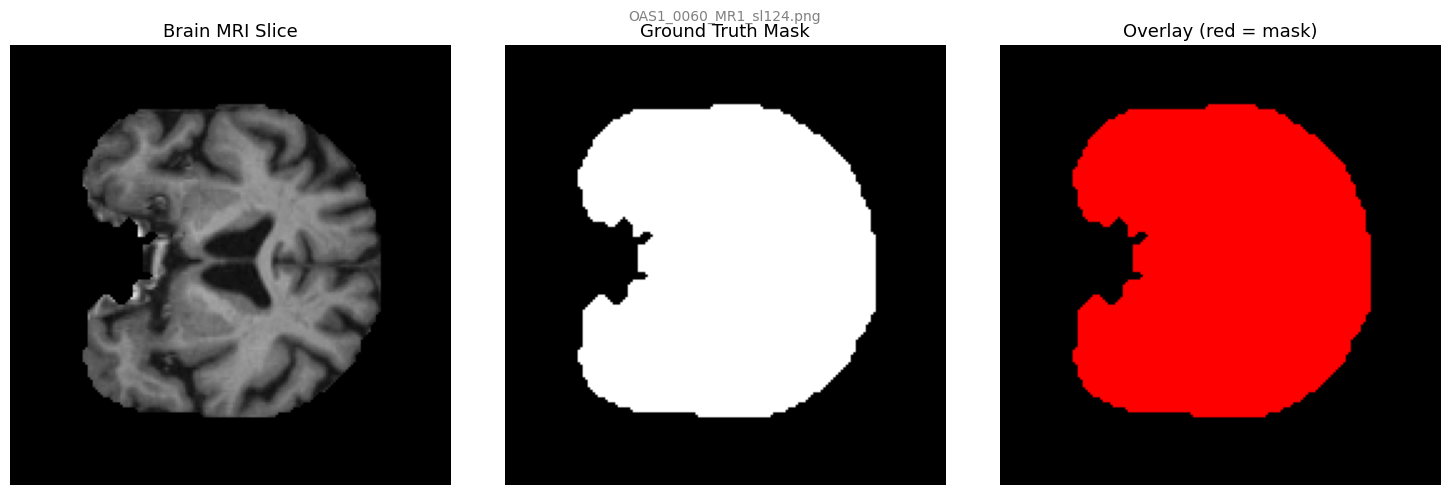

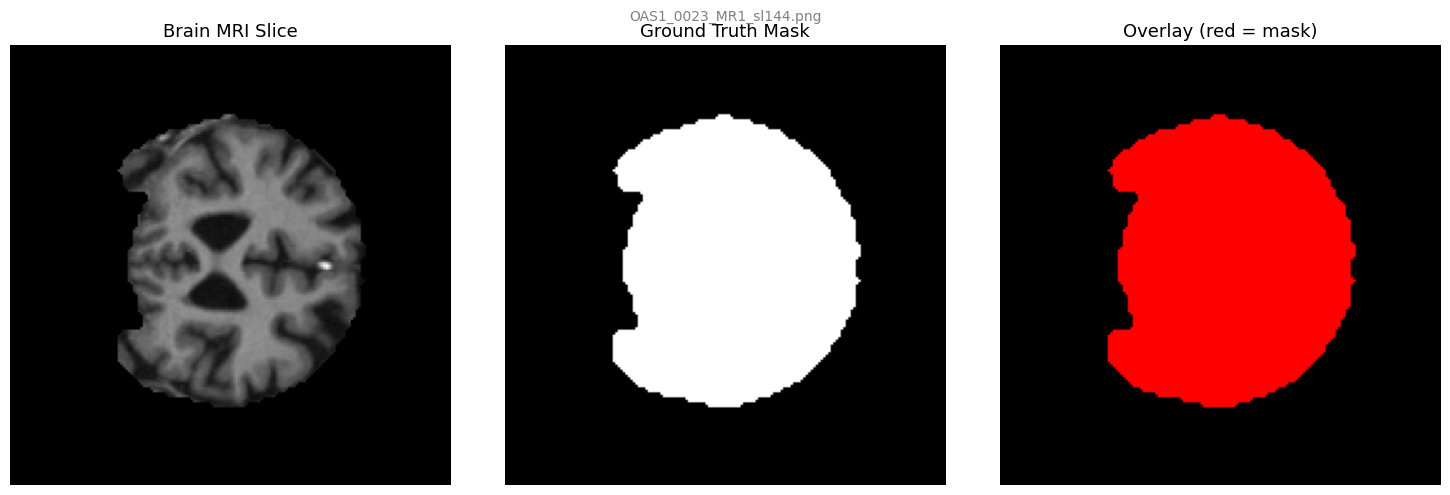

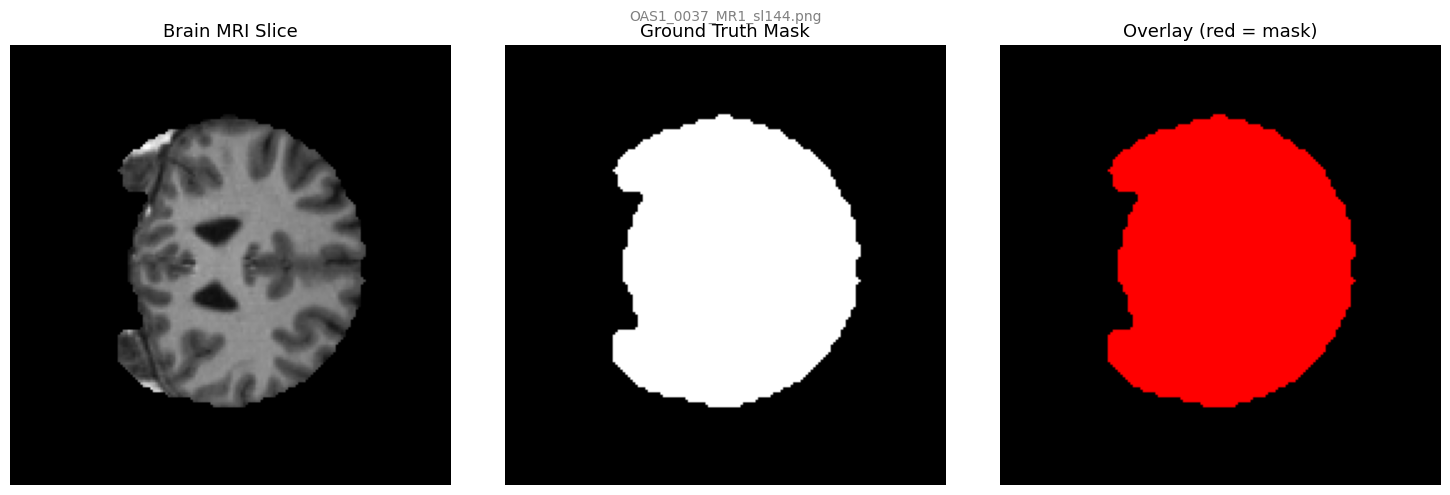

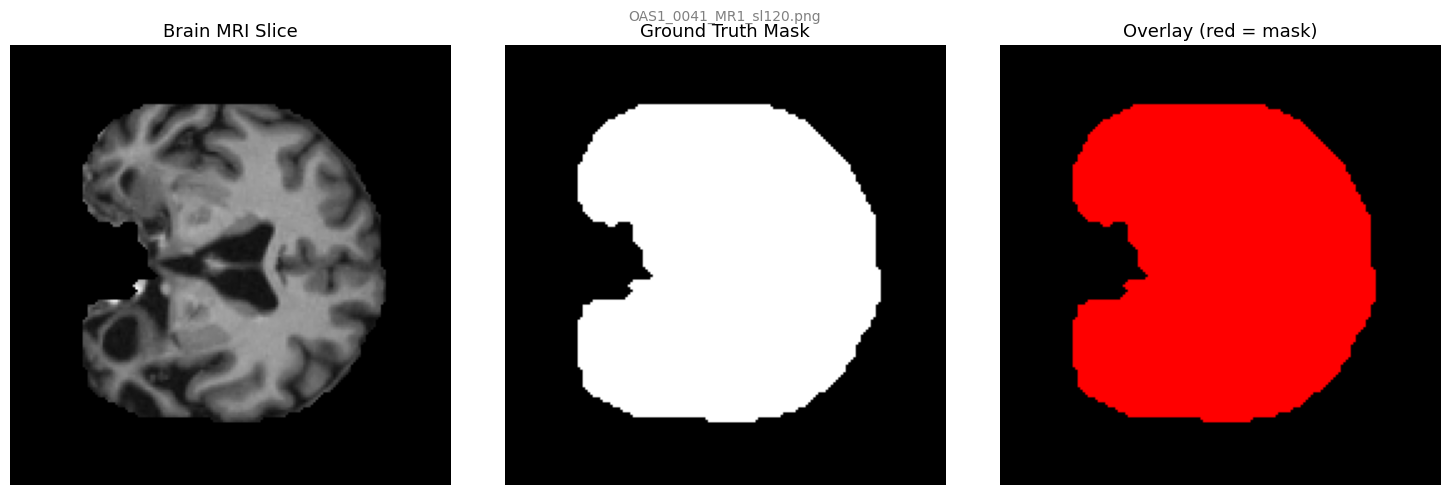

In [19]:
def visualize_sample(image_name, img_dir=IMAGE_FOLDER, mask_dir=MASK_FOLDER):
    img  = cv2.imread(os.path.join(img_dir,  image_name), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(os.path.join(mask_dir, image_name), cv2.IMREAD_GRAYSCALE)

    overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    overlay[mask > 127, 0] = 255
    overlay[mask > 127, 1] = 0
    overlay[mask > 127, 2] = 0

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img,     cmap='gray');  axes[0].set_title('Brain MRI Slice',      fontsize=13)
    axes[1].imshow(mask,    cmap='gray');  axes[1].set_title('Ground Truth Mask',    fontsize=13)
    axes[2].imshow(overlay);               axes[2].set_title('Overlay (red = mask)', fontsize=13)
    for ax in axes: ax.axis('off')
    plt.suptitle(image_name, fontsize=10, color='gray')
    plt.tight_layout()
    plt.show()


all_images = os.listdir(IMAGE_FOLDER)
for _ in range(4):
    visualize_sample(random.choice(all_images))

## 5. Train / Test Split

In [20]:
images = sorted([f for f in os.listdir(IMAGE_FOLDER) if f.endswith('.png')])
masks  = sorted([f for f in os.listdir(MASK_FOLDER)  if f.endswith('.png')])

assert images == masks, 'Image-mask mismatch! Check filenames.'

train_imgs, test_imgs = train_test_split(images, test_size=TEST_SPLIT, random_state=SEED)
print(f'Train: {len(train_imgs)}  |  Test: {len(test_imgs)}')

def copy_files(file_list, src_img, src_mask, dst_img, dst_mask):
    for f in tqdm(file_list, leave=False):
        shutil.copy(os.path.join(src_img,  f), os.path.join(dst_img,  f))
        shutil.copy(os.path.join(src_mask, f), os.path.join(dst_mask, f))

copy_files(train_imgs, IMAGE_FOLDER, MASK_FOLDER, TRAIN_IMG_DIR, TRAIN_MASK_DIR)
copy_files(test_imgs,  IMAGE_FOLDER, MASK_FOLDER, TEST_IMG_DIR,  TEST_MASK_DIR)
print('Files copied ✓')

Train: 5628  |  Test: 994


  0%|          | 0/5628 [00:00<?, ?it/s]

  0%|          | 0/994 [00:00<?, ?it/s]

Files copied ✓


## 6. tf.data Pipeline

In [21]:
def load_image(img_path, mask_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, IMG_SIZE, method='nearest')
    mask = tf.cast(mask, tf.float32) / 255.0

    return img, mask


def augment(img, mask):
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    img = tf.image.random_brightness(img, max_delta=0.05)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, mask


def build_dataset(img_dir, mask_dir, augment_data=False, batch=BATCH_SIZE):
    img_files  = sorted([os.path.join(img_dir,  f) for f in os.listdir(img_dir)  if f.endswith('.png')])
    mask_files = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith('.png')])

    ds = tf.data.Dataset.from_tensor_slices((img_files, mask_files))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds


train_dataset = build_dataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, augment_data=True)
test_dataset  = build_dataset(TEST_IMG_DIR,  TEST_MASK_DIR,  augment_data=False)

print('Datasets ready ✓')
for imgs, masks in train_dataset.take(1):
    print('Batch shapes →  images:', imgs.shape, ' masks:', masks.shape)

Datasets ready ✓
Batch shapes →  images: (16, 224, 224, 3)  masks: (16, 224, 224, 1)


## 7. Model — VGG19 Encoder + UNet++ (Nested) Decoder
**Combines two ideas:**
- **VGG19 backbone** — deeper encoder than VGG16 (4 conv layers per block in blocks 3-5 instead of 3), ~20M base params
- **UNet++ nested decoder** — dense skip pathways: each node `X(i,j)` aggregates the previous node at the same depth plus the upsampled node one level deeper, instead of a single skip connection per level. This reduces the semantic gap between encoder and decoder features.

In [22]:
def conv_block(x, filters, name_prefix):
    """Two Conv2D + BN + ReLU layers — the basic node operation in UNet++."""
    x = Conv2D(filters, (3,3), padding='same', name=f'{name_prefix}_c1')(x)
    x = BatchNormalization(name=f'{name_prefix}_bn1')(x)
    x = Activation('relu', name=f'{name_prefix}_act1')(x)
    x = Conv2D(filters, (3,3), padding='same', name=f'{name_prefix}_c2')(x)
    x = BatchNormalization(name=f'{name_prefix}_bn2')(x)
    x = Activation('relu', name=f'{name_prefix}_act2')(x)
    return x


def up(x, name):
    return UpSampling2D((2, 2), name=name)(x)


def build_vgg19_unetpp(input_shape=(224, 224, 3), freeze_encoder=True, deep_supervision=False):
    """
    VGG19 encoder (ImageNet weights) as backbone X(i,0) column,
    UNet++ nested dense decoder for X(i,j) with j>0.

    Encoder depths (i = 0..4), matching VGG19 blocks (last conv of each block):
      X(0,0) = block1_conv2   224x224,  64ch
      X(1,0) = block2_conv2   112x112, 128ch
      X(2,0) = block3_conv4    56x56,  256ch   (conv4, VGG19 has 4 convs here)
      X(3,0) = block4_conv4    28x28,  512ch   (conv4, VGG19 has 4 convs here)
      X(4,0) = block5_conv4    14x14,  512ch   (conv4, bottleneck)
    """
    inputs = Input(shape=input_shape, name='input')
    base = VGG19(include_top=False, weights='imagenet', input_tensor=inputs)

    if freeze_encoder:
        for layer in base.layers:
            layer.trainable = False

    # ── Backbone column (j = 0) ───────────────────────────────────────────────
    X00 = base.get_layer('block1_conv2').output   # 224x224,  64
    X10 = base.get_layer('block2_conv2').output   # 112x112, 128
    X20 = base.get_layer('block3_conv4').output   #  56x56,  256
    X30 = base.get_layer('block4_conv4').output   #  28x28,  512
    X40 = base.get_layer('block5_conv4').output   #  14x14,  512

    F = [64, 128, 256, 512, 512]   # channel width per depth level

    # ── Nested dense decoder ────────────────────────────────────────────────
    # j = 1
    X01 = conv_block(concatenate([X00, up(X10, 'up10_01')]), F[0], 'X01')
    X11 = conv_block(concatenate([X10, up(X20, 'up20_11')]), F[1], 'X11')
    X21 = conv_block(concatenate([X20, up(X30, 'up30_21')]), F[2], 'X21')
    X31 = conv_block(concatenate([X30, up(X40, 'up40_31')]), F[3], 'X31')

    # j = 2
    X02 = conv_block(concatenate([X00, X01, up(X11, 'up11_02')]), F[0], 'X02')
    X12 = conv_block(concatenate([X10, X11, up(X21, 'up21_12')]), F[1], 'X12')
    X22 = conv_block(concatenate([X20, X21, up(X31, 'up31_22')]), F[2], 'X22')

    # j = 3
    X03 = conv_block(concatenate([X00, X01, X02, up(X12, 'up12_03')]), F[0], 'X03')
    X13 = conv_block(concatenate([X10, X11, X12, up(X22, 'up22_13')]), F[1], 'X13')

    # j = 4 (final, full-resolution node)
    X04 = conv_block(concatenate([X00, X01, X02, X03, up(X13, 'up13_04')]), F[0], 'X04')

    # ── Output(s) ──────────────────────────────────────────────────────────
    out4 = Conv2D(1, (1,1), activation='sigmoid', name='output')(X04)

    if deep_supervision:
        out1 = Conv2D(1, (1,1), activation='sigmoid', name='out1')(X01)
        out2 = Conv2D(1, (1,1), activation='sigmoid', name='out2')(X02)
        out3 = Conv2D(1, (1,1), activation='sigmoid', name='out3')(X03)
        model = Model(inputs=inputs, outputs=[out1, out2, out3, out4], name='VGG19_UNetPP_DS')
    else:
        model = Model(inputs=inputs, outputs=out4, name='VGG19_UNetPP')

    return model


# Single-output mode keeps metric/callback code identical to plain UNet & VGG16-UNet++ notebooks.
DEEP_SUPERVISION = False

model = build_vgg19_unetpp(input_shape=(*IMG_SIZE, 3), freeze_encoder=True, deep_supervision=DEEP_SUPERVISION)
print('Model built ✓')
print(f'Total parameters      : {model.count_params():,}')
print(f'Trainable parameters  : {sum([K.count_params(w) for w in model.trainable_weights]):,}')

Model built ✓
Total parameters      : 35,450,241
Trainable parameters  : 15,419,201


## 8. Custom Metrics & Loss

In [23]:
def dice_coefficient(y_true, y_pred, smooth=1.0):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)


def iou_score(y_true, y_pred, smooth=1.0):
    """Intersection over Union (Jaccard Index)"""
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)


def precision_smooth(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return intersection / (K.sum(y_pred_f) + K.epsilon())


def recall_smooth(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return intersection / (K.sum(y_true_f) + K.epsilon())


def pixel_accuracy(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    tp = K.sum(K.round(K.clip(y_true_f * y_pred_f, 0, 1)))
    tn = K.sum(K.round(K.clip((1 - y_true_f) * (1 - y_pred_f), 0, 1)))
    total = K.cast(tf.size(y_true_f), K.floatx())
    return (tp + tn) / total


def combined_loss(y_true, y_pred):
    return dice_loss(y_true, y_pred) + tf.keras.losses.binary_crossentropy(y_true, y_pred)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=[dice_coefficient, iou_score, precision_smooth, recall_smooth, pixel_accuracy]
)

print('Model compiled ✓')

Model compiled ✓


## 9. Model Summary & Architecture Plot

In [24]:
model.summary()

try:
    tf.keras.utils.plot_model(
        model,
        to_file='vgg19_unetpp_architecture.png',
        show_shapes=True,
        show_layer_names=True,
        rankdir='TB',
        dpi=60
    )
    print('Architecture diagram saved ✓')
except Exception as e:
    print('Architecture plot skipped (graph too complex for Graphviz):', str(e)[:150])

Model: "VGG19_UNetPP"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input[0][0]       │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv4        │ (None, 56, 56,    │    590,080 │ block3_conv3[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv4[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv4        │ (None, 28, 28,    │  2,359,808 │ block4_conv3[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv4[0][

 Total params: 35,450,241 (135.23 MB)

 Trainable params: 15,419,201 (58.82 MB)

 Non-trainable params: 20,031,040 (76.41 MB)

"dot" with args ['-Tpng', '/tmp/tmpxty7aw1l/tmpvr_k360s'] returned code: -6

stdout, stderr:
 b''
b"failed at node 6830[0]\ndot: maze.c:311: chkSgraph: Assertion `np->cells[0]' failed.\n"

Architecture plot skipped (graph too complex for Graphviz): "dot" with args ['-Tpng', '/tmp/tmpxty7aw1l/tmpvr_k360s'] returned code: -6


## 10. Callbacks  (EarlyStopping disabled — full epochs as instructed)

In [25]:
def create_mask(pred):
    return tf.math.round(pred)


def show_predictions(dataset, num=3, model_to_use=None):
    m = model_to_use or model
    for imgs, masks in dataset.take(1):
        preds = m.predict(imgs, verbose=0)
        for i in range(min(num, len(imgs))):
            pred_mask = create_mask(preds[i])
            fig, axes = plt.subplots(1, 3, figsize=(12, 4))
            axes[0].imshow(imgs[i].numpy());            axes[0].set_title('Input MRI')
            axes[1].imshow(masks[i].numpy()[..., 0], cmap='gray'); axes[1].set_title('Ground Truth')
            axes[2].imshow(pred_mask.numpy()[..., 0], cmap='gray'); axes[2].set_title('Prediction')
            for ax in axes: ax.axis('off')
            plt.tight_layout()
            plt.show()


class DisplayCallback(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            show_predictions(test_dataset, num=2)
            print(f'Prediction after epoch {epoch + 1}\n')


logdir = os.path.join('logs', datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))

callbacks_list = [
    DisplayCallback(),
    callbacks.TensorBoard(logdir, histogram_freq=1),
    callbacks.ModelCheckpoint('best_model_vgg19unetpp.keras', verbose=1, save_best_only=True,
                               monitor='val_iou_score', mode='max'),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                                 min_lr=1e-7, verbose=1),
    # EarlyStopping intentionally removed — train for the full EPOCHS as instructed
]

print('Callbacks ready ✓ (no EarlyStopping — will run all', EPOCHS, 'epochs)')

Callbacks ready ✓ (no EarlyStopping — will run all 100 epochs)


## 11. Initial Predictions (before training)

Predictions before training:


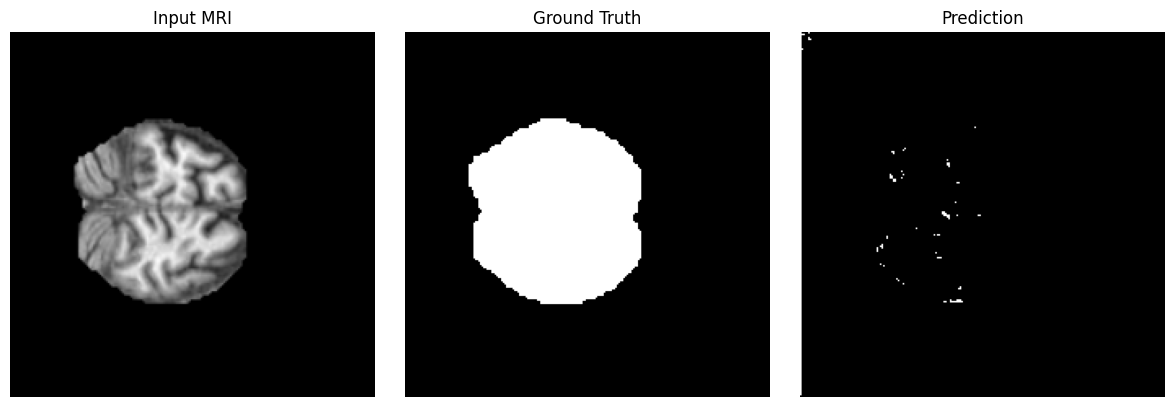

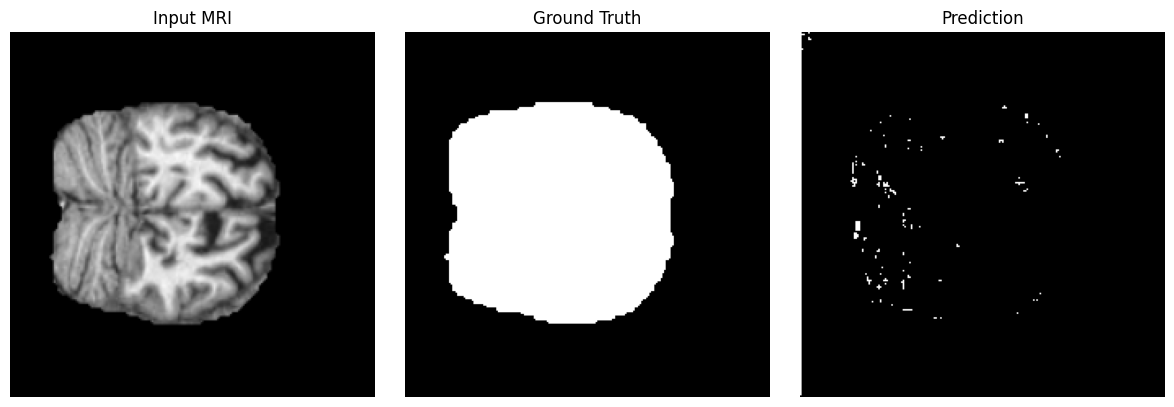

In [26]:
print('Predictions before training:')
show_predictions(test_dataset, num=2)

## 12. Training

Steps per epoch  : 351
Validation steps : 62
Epoch 1/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - dice_coefficient: 0.8627 - iou_score: 0.7827 - loss: 0.2314 - pixel_accuracy: 0.9778 - precision_smooth: 0.8009 - recall_smooth: 0.9642
Epoch 1: val_iou_score improved from None to 0.92442, saving model to best_model_vgg19unetpp.keras

Epoch 1: finished saving model to best_model_vgg19unetpp.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 280s 725ms/step - dice_coefficient: 0.9101 - iou_score: 0.8488 - loss: 0.1390 - pixel_accuracy: 0.9940 - precision_smooth: 0.8586 - recall_smooth: 0.9859 - val_dice_coefficient: 0.9607 - val_iou_score: 0.9244 - val_loss: 0.0659 - val_pixel_accuracy: 0.9985 - val_precision_smooth: 0.9289 - val_recall_smooth: 0.9948 - learning_rate: 1.0000e-04
Epoch 2/100
  1/351 ━━━━━━━━━━━━━━━━━━━━ 1:08:04 12s/step - dice_coefficient: 0.8354 - iou_score: 0.7174 - loss: 0.2143 - pixel_accuracy: 0.9988 - precision_smooth: 0.7208 - recall_smooth: 0.9934
Epoch 2: val_iou_score did not

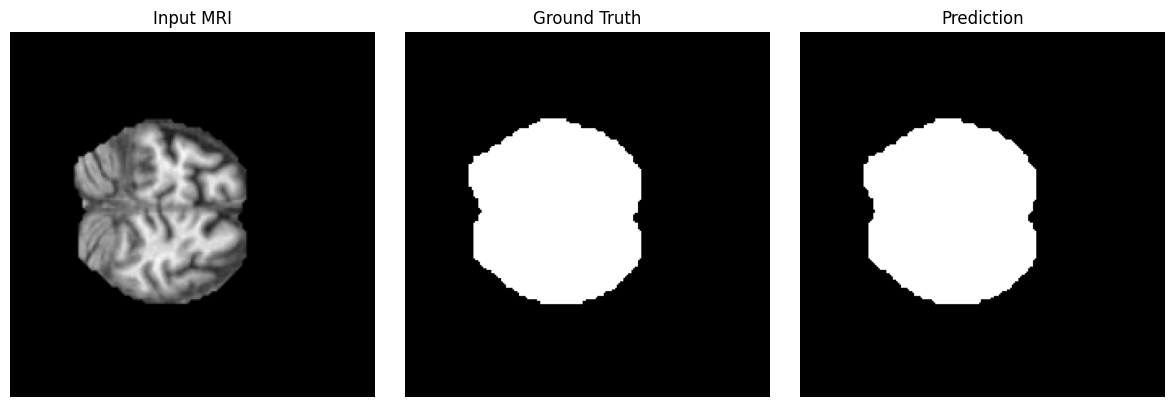

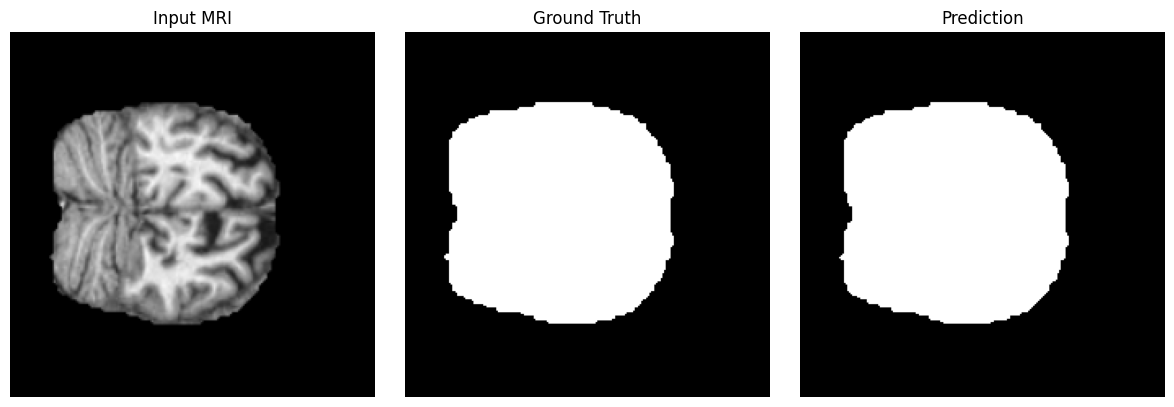

Prediction after epoch 10


Epoch 10: val_iou_score did not improve from 0.98972
351/351 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - dice_coefficient: 0.9639 - iou_score: 0.9304 - loss: 0.0456 - pixel_accuracy: 0.9995 - precision_smooth: 0.9327 - recall_smooth: 0.9973 - val_dice_coefficient: 0.9948 - val_iou_score: 0.9896 - val_loss: 0.0092 - val_pixel_accuracy: 0.9993 - val_precision_smooth: 0.9905 - val_recall_smooth: 0.9991 - learning_rate: 1.0000e-04
Epoch 11/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 643ms/step - dice_coefficient: 0.9895 - iou_score: 0.9796 - loss: 0.0150 - pixel_accuracy: 0.9994 - precision_smooth: 0.9816 - recall_smooth: 0.9980
Epoch 11: val_iou_score improved from 0.98972 to 0.99215, saving model to best_model_vgg19unetpp.keras

Epoch 11: finished saving model to best_model_vgg19unetpp.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 249s 711ms/step - dice_coefficient: 0.9900 - iou_score: 0.9805 - loss: 0.0143 - pixel_accuracy: 0.9994 - precision_smooth: 0.9824 - recall_smooth: 0.9980 - v

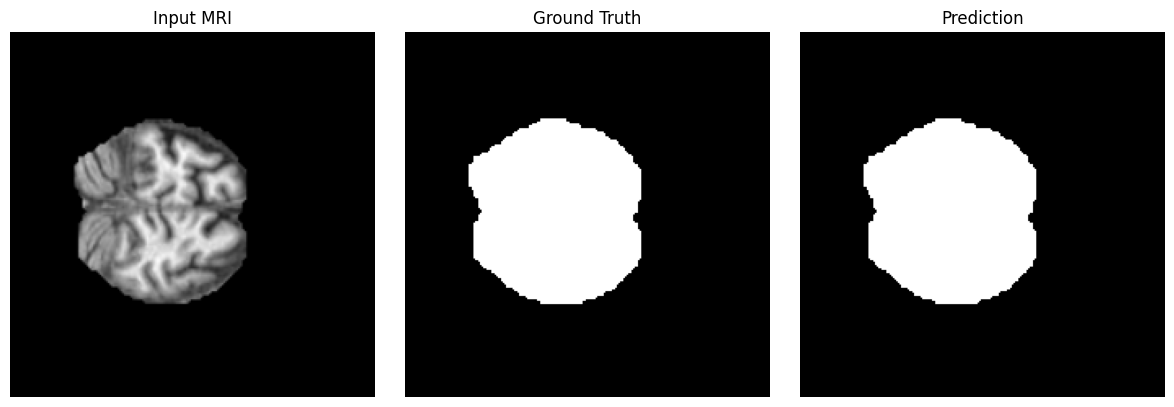

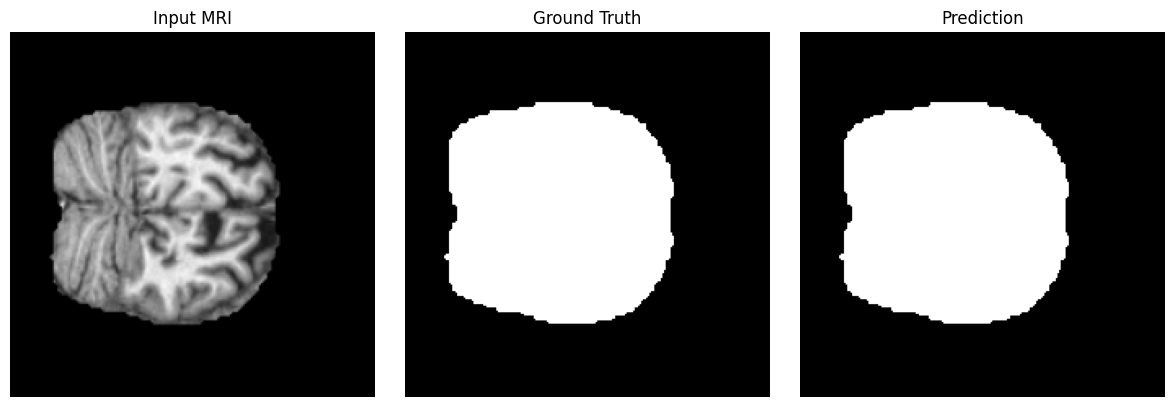

Prediction after epoch 20


Epoch 20: val_iou_score did not improve from 0.99820
351/351 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - dice_coefficient: 0.9899 - iou_score: 0.9801 - loss: 0.0127 - pixel_accuracy: 0.9999 - precision_smooth: 0.9814 - recall_smooth: 0.9986 - val_dice_coefficient: 0.9991 - val_iou_score: 0.9981 - val_loss: 0.0016 - val_pixel_accuracy: 0.9999 - val_precision_smooth: 0.9984 - val_recall_smooth: 0.9998 - learning_rate: 1.0000e-04
Epoch 21/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - dice_coefficient: 0.9972 - iou_score: 0.9945 - loss: 0.0039 - pixel_accuracy: 0.9999 - precision_smooth: 0.9951 - recall_smooth: 0.9994
Epoch 21: val_iou_score improved from 0.99820 to 0.99821, saving model to best_model_vgg19unetpp.keras

Epoch 21: finished saving model to best_model_vgg19unetpp.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 250s 712ms/step - dice_coefficient: 0.9973 - iou_score: 0.9947 - loss: 0.0038 - pixel_accuracy: 0.9999 - precision_smooth: 0.9952 - recall_smooth: 0.9995 - v

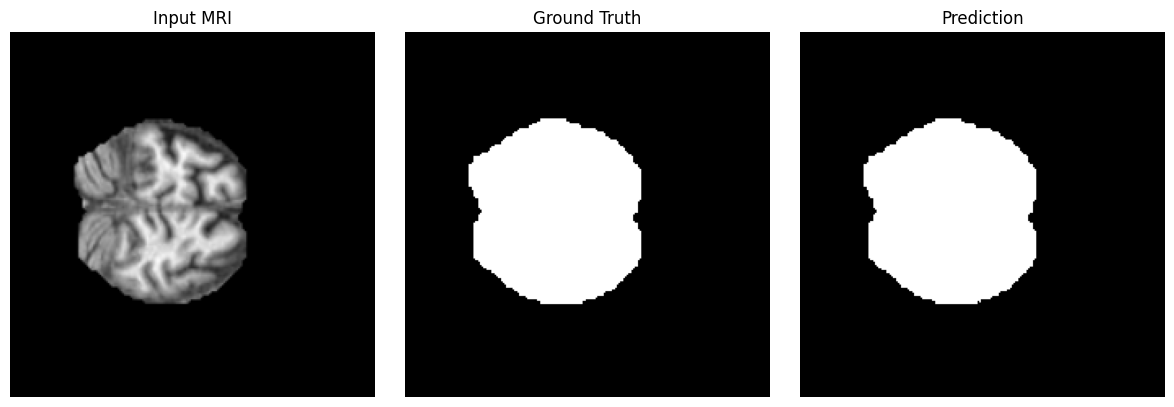

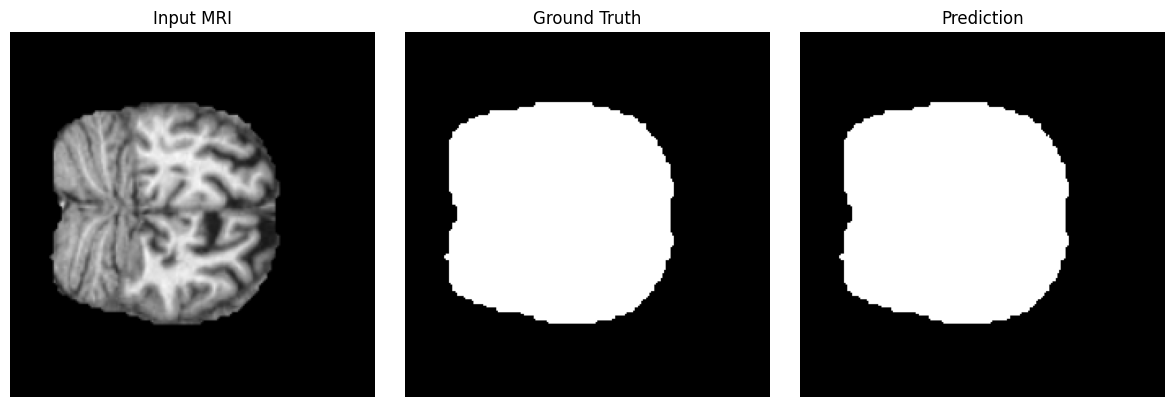

Prediction after epoch 30


Epoch 30: val_iou_score did not improve from 0.99898
351/351 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - dice_coefficient: 0.9956 - iou_score: 0.9912 - loss: 0.0055 - pixel_accuracy: 1.0000 - precision_smooth: 0.9915 - recall_smooth: 0.9997 - val_dice_coefficient: 0.9993 - val_iou_score: 0.9987 - val_loss: 0.0012 - val_pixel_accuracy: 0.9999 - val_precision_smooth: 0.9987 - val_recall_smooth: 1.0000 - learning_rate: 5.0000e-05
Epoch 31/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - dice_coefficient: 0.9988 - iou_score: 0.9976 - loss: 0.0017 - pixel_accuracy: 1.0000 - precision_smooth: 0.9978 - recall_smooth: 0.9998
Epoch 31: val_iou_score improved from 0.99898 to 0.99929, saving model to best_model_vgg19unetpp.keras

Epoch 31: finished saving model to best_model_vgg19unetpp.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 299s 711ms/step - dice_coefficient: 0.9988 - iou_score: 0.9976 - loss: 0.0017 - pixel_accuracy: 1.0000 - precision_smooth: 0.9978 - recall_smooth: 0.9998 - v

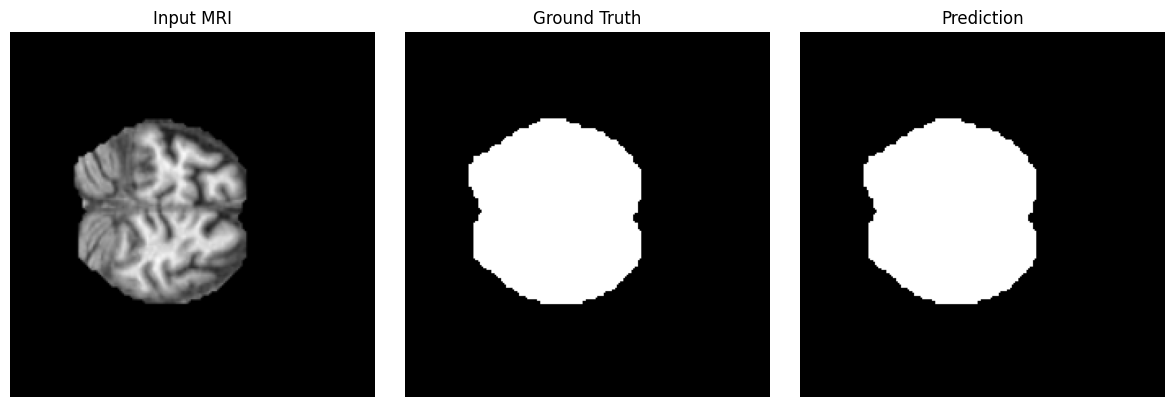

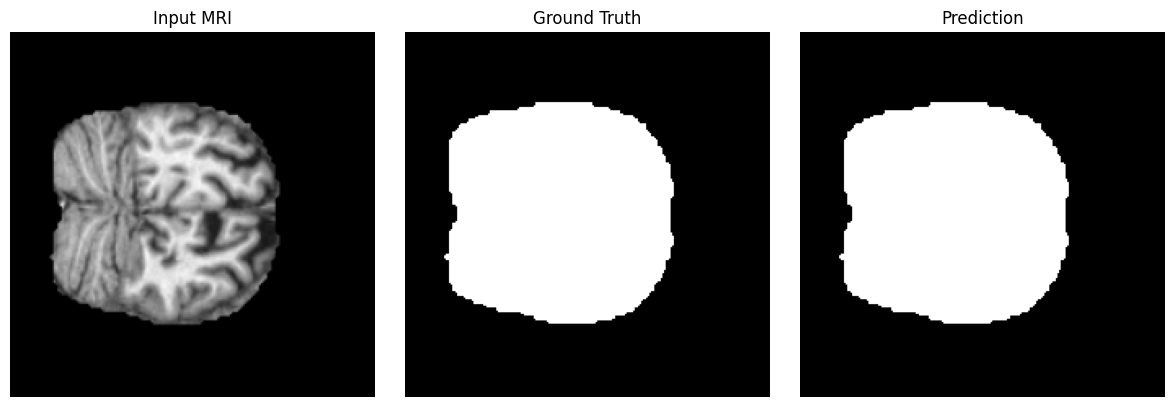

Prediction after epoch 40


Epoch 40: val_iou_score improved from 0.99948 to 0.99949, saving model to best_model_vgg19unetpp.keras

Epoch 40: finished saving model to best_model_vgg19unetpp.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - dice_coefficient: 0.9975 - iou_score: 0.9951 - loss: 0.0031 - pixel_accuracy: 1.0000 - precision_smooth: 0.9951 - recall_smooth: 1.0000 - val_dice_coefficient: 0.9997 - val_iou_score: 0.9995 - val_loss: 4.4862e-04 - val_pixel_accuracy: 1.0000 - val_precision_smooth: 0.9995 - val_recall_smooth: 1.0000 - learning_rate: 2.5000e-05
Epoch 41/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 643ms/step - dice_coefficient: 0.9993 - iou_score: 0.9986 - loss: 9.6724e-04 - pixel_accuracy: 1.0000 - precision_smooth: 0.9987 - recall_smooth: 0.9999
Epoch 41: val_iou_score improved from 0.99949 to 0.99964, saving model to best_model_vgg19unetpp.keras

Epoch 41: finished saving model to best_model_vgg19unetpp.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 249s 710ms/step - dice_coefficient

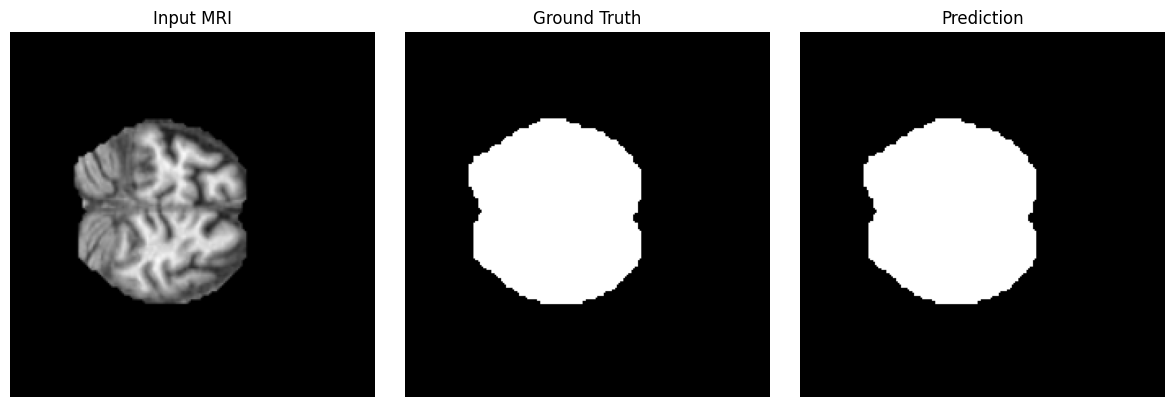

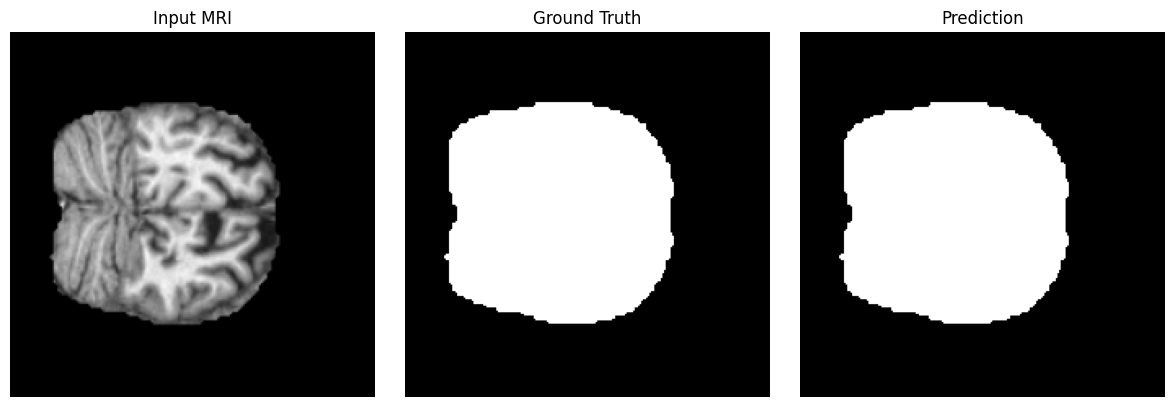

Prediction after epoch 50


Epoch 50: val_iou_score did not improve from 0.99964
351/351 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - dice_coefficient: 0.9983 - iou_score: 0.9966 - loss: 0.0021 - pixel_accuracy: 1.0000 - precision_smooth: 0.9966 - recall_smooth: 1.0000 - val_dice_coefficient: 0.9998 - val_iou_score: 0.9995 - val_loss: 4.2605e-04 - val_pixel_accuracy: 1.0000 - val_precision_smooth: 0.9996 - val_recall_smooth: 1.0000 - learning_rate: 1.2500e-05
Epoch 51/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - dice_coefficient: 0.9995 - iou_score: 0.9990 - loss: 6.5128e-04 - pixel_accuracy: 1.0000 - precision_smooth: 0.9991 - recall_smooth: 0.9999
Epoch 51: val_iou_score did not improve from 0.99964

Epoch 51: ReduceLROnPlateau reducing learning rate to 6.24999984211172e-06.
351/351 ━━━━━━━━━━━━━━━━━━━━ 248s 708ms/step - dice_coefficient: 0.9995 - iou_score: 0.9990 - loss: 6.7233e-04 - pixel_accuracy: 1.0000 - precision_smooth: 0.9991 - recall_smooth: 0.9999 - val_dice_coefficient: 0.999

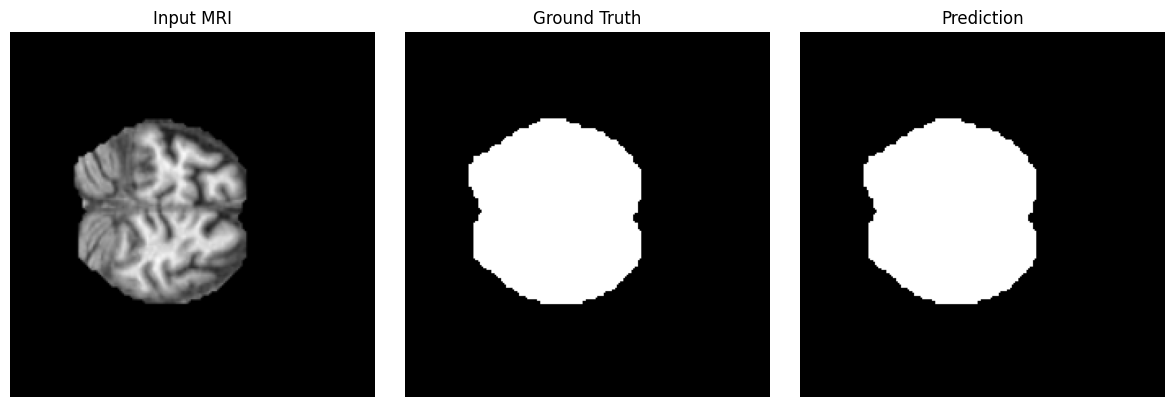

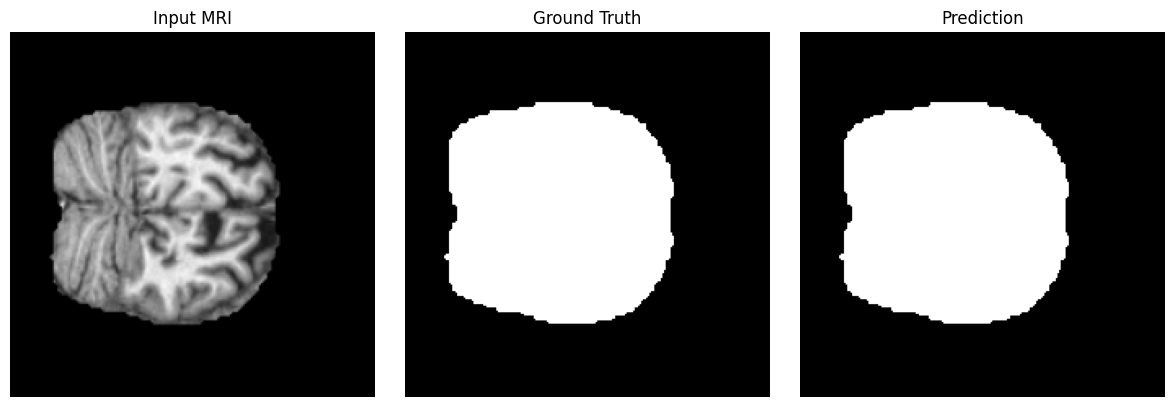

Prediction after epoch 60


Epoch 60: val_iou_score did not improve from 0.99966
351/351 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - dice_coefficient: 0.9985 - iou_score: 0.9970 - loss: 0.0019 - pixel_accuracy: 1.0000 - precision_smooth: 0.9971 - recall_smooth: 1.0000 - val_dice_coefficient: 0.9998 - val_iou_score: 0.9996 - val_loss: 3.5279e-04 - val_pixel_accuracy: 1.0000 - val_precision_smooth: 0.9996 - val_recall_smooth: 1.0000 - learning_rate: 3.1250e-06
Epoch 61/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 643ms/step - dice_coefficient: 0.9996 - iou_score: 0.9992 - loss: 5.5052e-04 - pixel_accuracy: 1.0000 - precision_smooth: 0.9992 - recall_smooth: 0.9999
Epoch 61: val_iou_score did not improve from 0.99966

Epoch 61: ReduceLROnPlateau reducing learning rate to 1.56249996052793e-06.
351/351 ━━━━━━━━━━━━━━━━━━━━ 248s 707ms/step - dice_coefficient: 0.9996 - iou_score: 0.9992 - loss: 5.6981e-04 - pixel_accuracy: 1.0000 - precision_smooth: 0.9992 - recall_smooth: 0.9999 - val_dice_coefficient: 0.999

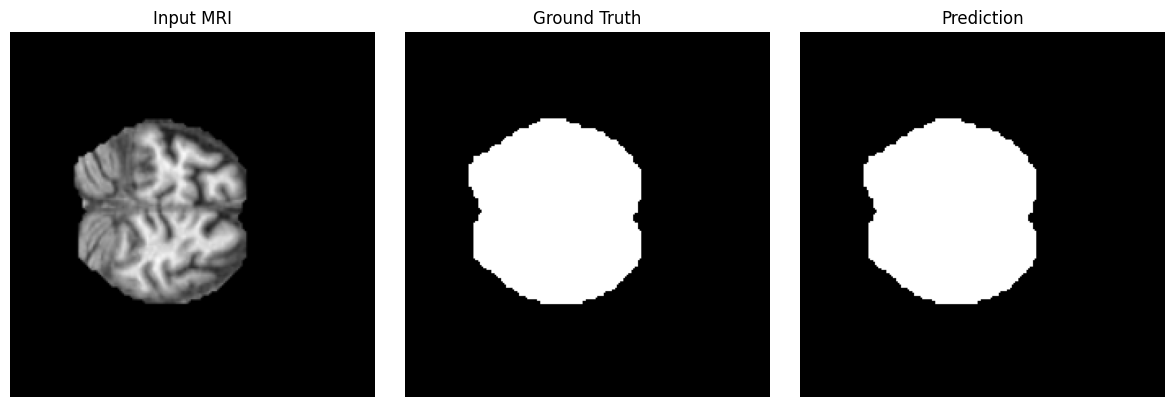

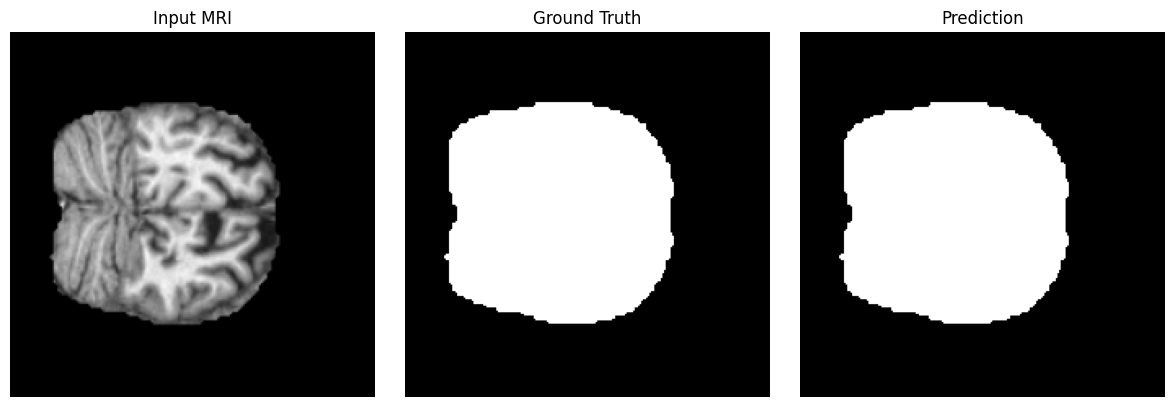

Prediction after epoch 70


Epoch 70: val_iou_score did not improve from 0.99966
351/351 ━━━━━━━━━━━━━━━━━━━━ 42s 118ms/step - dice_coefficient: 0.9986 - iou_score: 0.9972 - loss: 0.0017 - pixel_accuracy: 1.0000 - precision_smooth: 0.9972 - recall_smooth: 1.0000 - val_dice_coefficient: 0.9998 - val_iou_score: 0.9997 - val_loss: 3.3014e-04 - val_pixel_accuracy: 1.0000 - val_precision_smooth: 0.9997 - val_recall_smooth: 1.0000 - learning_rate: 7.8125e-07
Epoch 71/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 643ms/step - dice_coefficient: 0.9996 - iou_score: 0.9992 - loss: 5.2539e-04 - pixel_accuracy: 1.0000 - precision_smooth: 0.9993 - recall_smooth: 0.9999
Epoch 71: val_iou_score did not improve from 0.99966

Epoch 71: ReduceLROnPlateau reducing learning rate to 3.906249901319825e-07.
351/351 ━━━━━━━━━━━━━━━━━━━━ 248s 706ms/step - dice_coefficient: 0.9996 - iou_score: 0.9992 - loss: 5.4122e-04 - pixel_accuracy: 1.0000 - precision_smooth: 0.9993 - recall_smooth: 0.9999 - val_dice_coefficient: 0.9

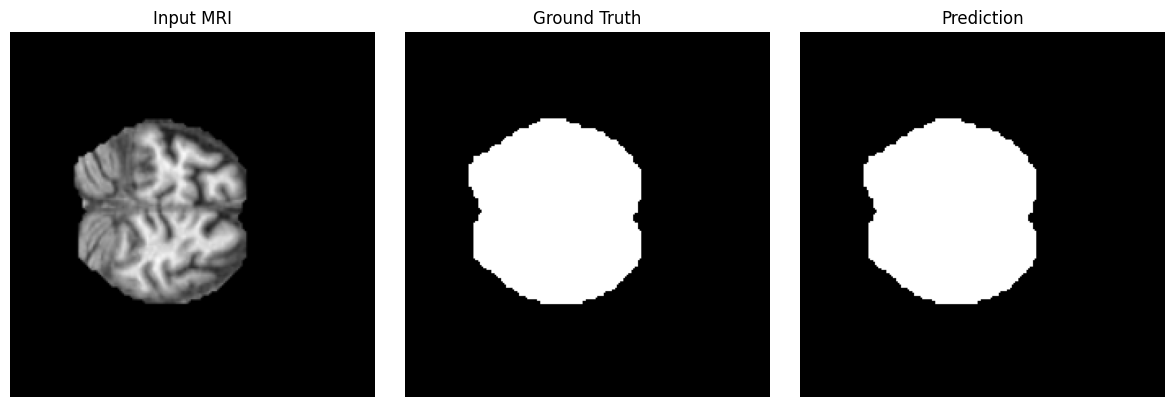

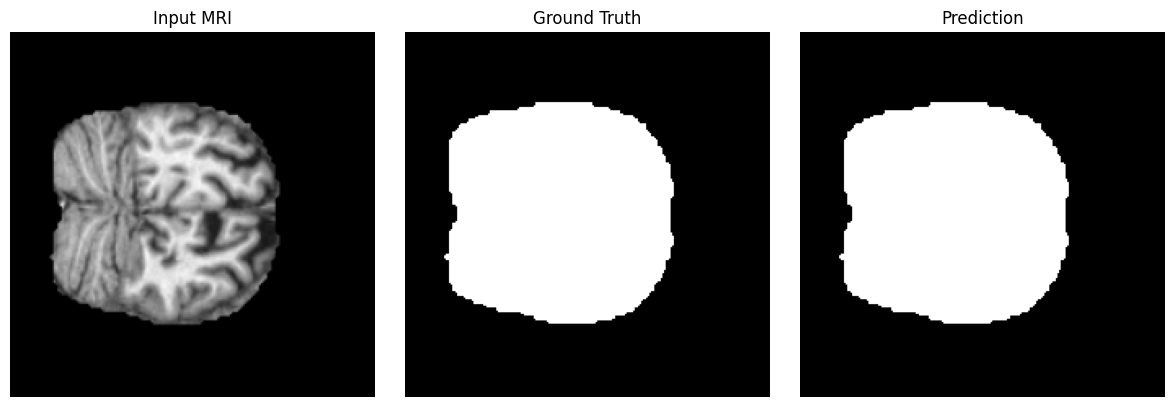

Prediction after epoch 80


Epoch 80: val_iou_score did not improve from 0.99966
351/351 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - dice_coefficient: 0.9986 - iou_score: 0.9972 - loss: 0.0018 - pixel_accuracy: 1.0000 - precision_smooth: 0.9973 - recall_smooth: 0.9999 - val_dice_coefficient: 0.9998 - val_iou_score: 0.9996 - val_loss: 3.3582e-04 - val_pixel_accuracy: 1.0000 - val_precision_smooth: 0.9997 - val_recall_smooth: 1.0000 - learning_rate: 1.9531e-07
Epoch 81/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - dice_coefficient: 0.9996 - iou_score: 0.9992 - loss: 5.1538e-04 - pixel_accuracy: 1.0000 - precision_smooth: 0.9993 - recall_smooth: 0.9999
Epoch 81: val_iou_score did not improve from 0.99966

Epoch 81: ReduceLROnPlateau reducing learning rate to 1e-07.
351/351 ━━━━━━━━━━━━━━━━━━━━ 248s 706ms/step - dice_coefficient: 0.9996 - iou_score: 0.9992 - loss: 5.3210e-04 - pixel_accuracy: 1.0000 - precision_smooth: 0.9993 - recall_smooth: 0.9999 - val_dice_coefficient: 0.9998 - val_iou_sco

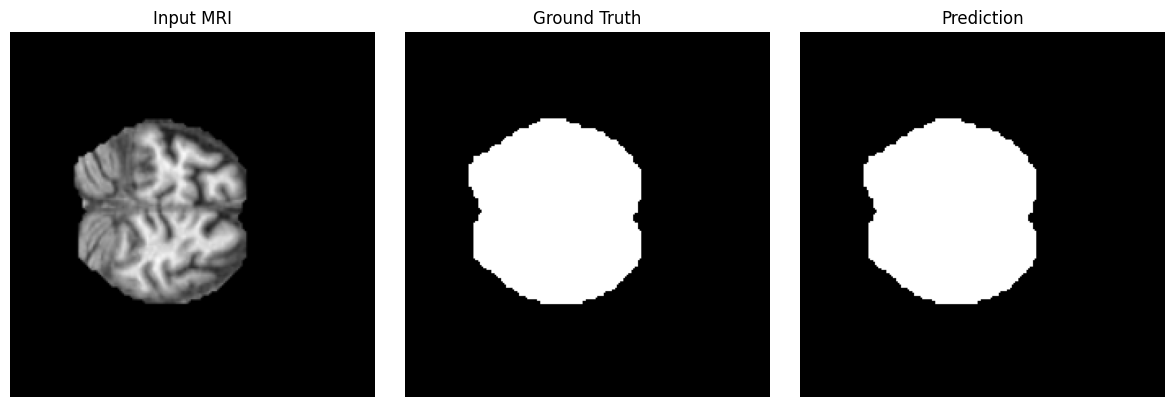

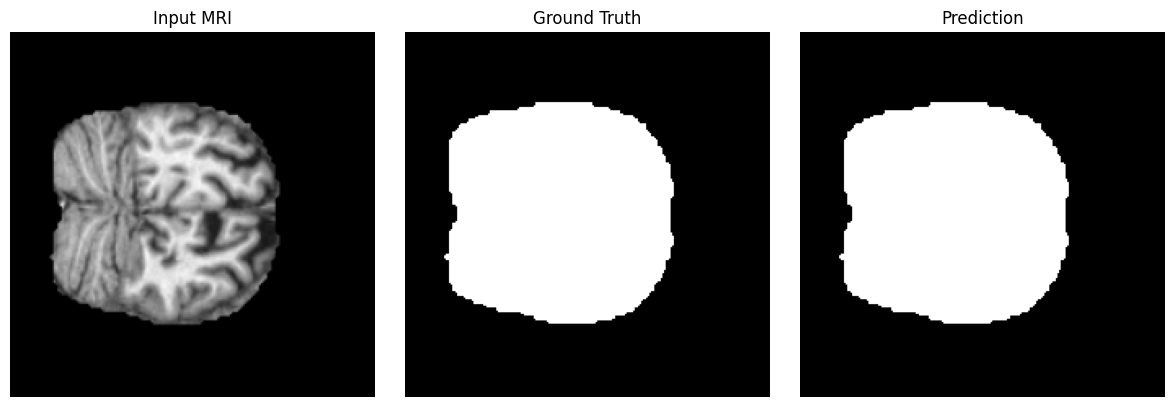

Prediction after epoch 90


Epoch 90: val_iou_score did not improve from 0.99966
351/351 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - dice_coefficient: 0.9986 - iou_score: 0.9973 - loss: 0.0017 - pixel_accuracy: 1.0000 - precision_smooth: 0.9973 - recall_smooth: 1.0000 - val_dice_coefficient: 0.9998 - val_iou_score: 0.9996 - val_loss: 3.3438e-04 - val_pixel_accuracy: 1.0000 - val_precision_smooth: 0.9997 - val_recall_smooth: 1.0000 - learning_rate: 1.0000e-07
Epoch 91/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - dice_coefficient: 0.9996 - iou_score: 0.9992 - loss: 5.1686e-04 - pixel_accuracy: 1.0000 - precision_smooth: 0.9993 - recall_smooth: 0.9999
Epoch 91: val_iou_score did not improve from 0.99966
351/351 ━━━━━━━━━━━━━━━━━━━━ 247s 704ms/step - dice_coefficient: 0.9996 - iou_score: 0.9992 - loss: 5.3537e-04 - pixel_accuracy: 1.0000 - precision_smooth: 0.9993 - recall_smooth: 0.9999 - val_dice_coefficient: 0.9998 - val_iou_score: 0.9997 - val_loss: 3.3166e-04 - val_pixel_accuracy: 1.0000

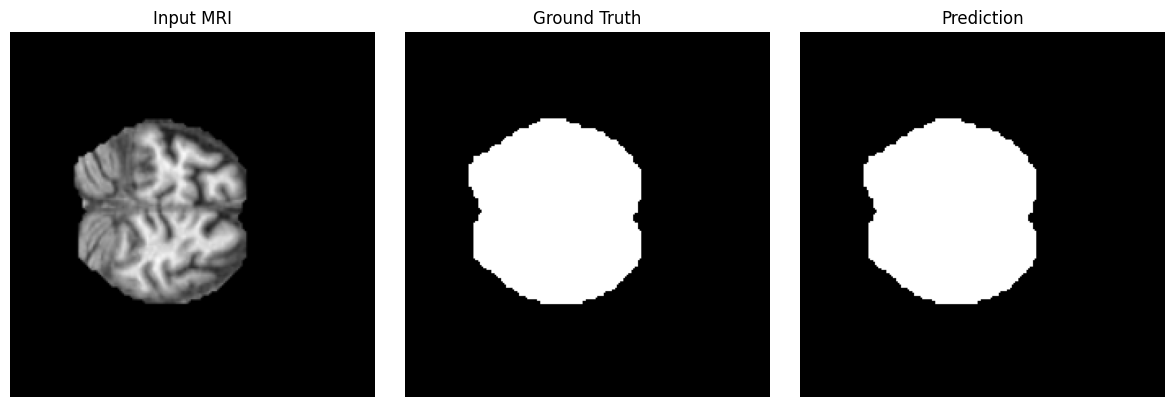

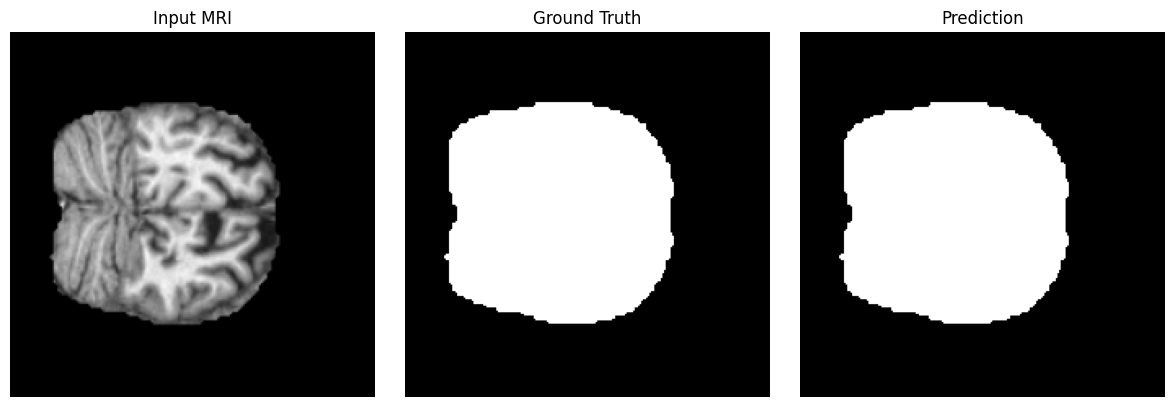

Prediction after epoch 100


Epoch 100: val_iou_score did not improve from 0.99966
351/351 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - dice_coefficient: 0.9986 - iou_score: 0.9973 - loss: 0.0017 - pixel_accuracy: 1.0000 - precision_smooth: 0.9973 - recall_smooth: 1.0000 - val_dice_coefficient: 0.9998 - val_iou_score: 0.9997 - val_loss: 3.3224e-04 - val_pixel_accuracy: 1.0000 - val_precision_smooth: 0.9997 - val_recall_smooth: 1.0000 - learning_rate: 1.0000e-07

Training time: 228.1 min


In [27]:
steps_per_epoch  = len(os.listdir(TRAIN_IMG_DIR)) // BATCH_SIZE
validation_steps = len(os.listdir(TEST_IMG_DIR))  // BATCH_SIZE

print(f'Steps per epoch  : {steps_per_epoch}')
print(f'Validation steps : {validation_steps}')

start_time = time.time()

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks_list
)

elapsed = time.time() - start_time
print(f'\nTraining time: {elapsed/60:.1f} min')

## 13. Training Graphs

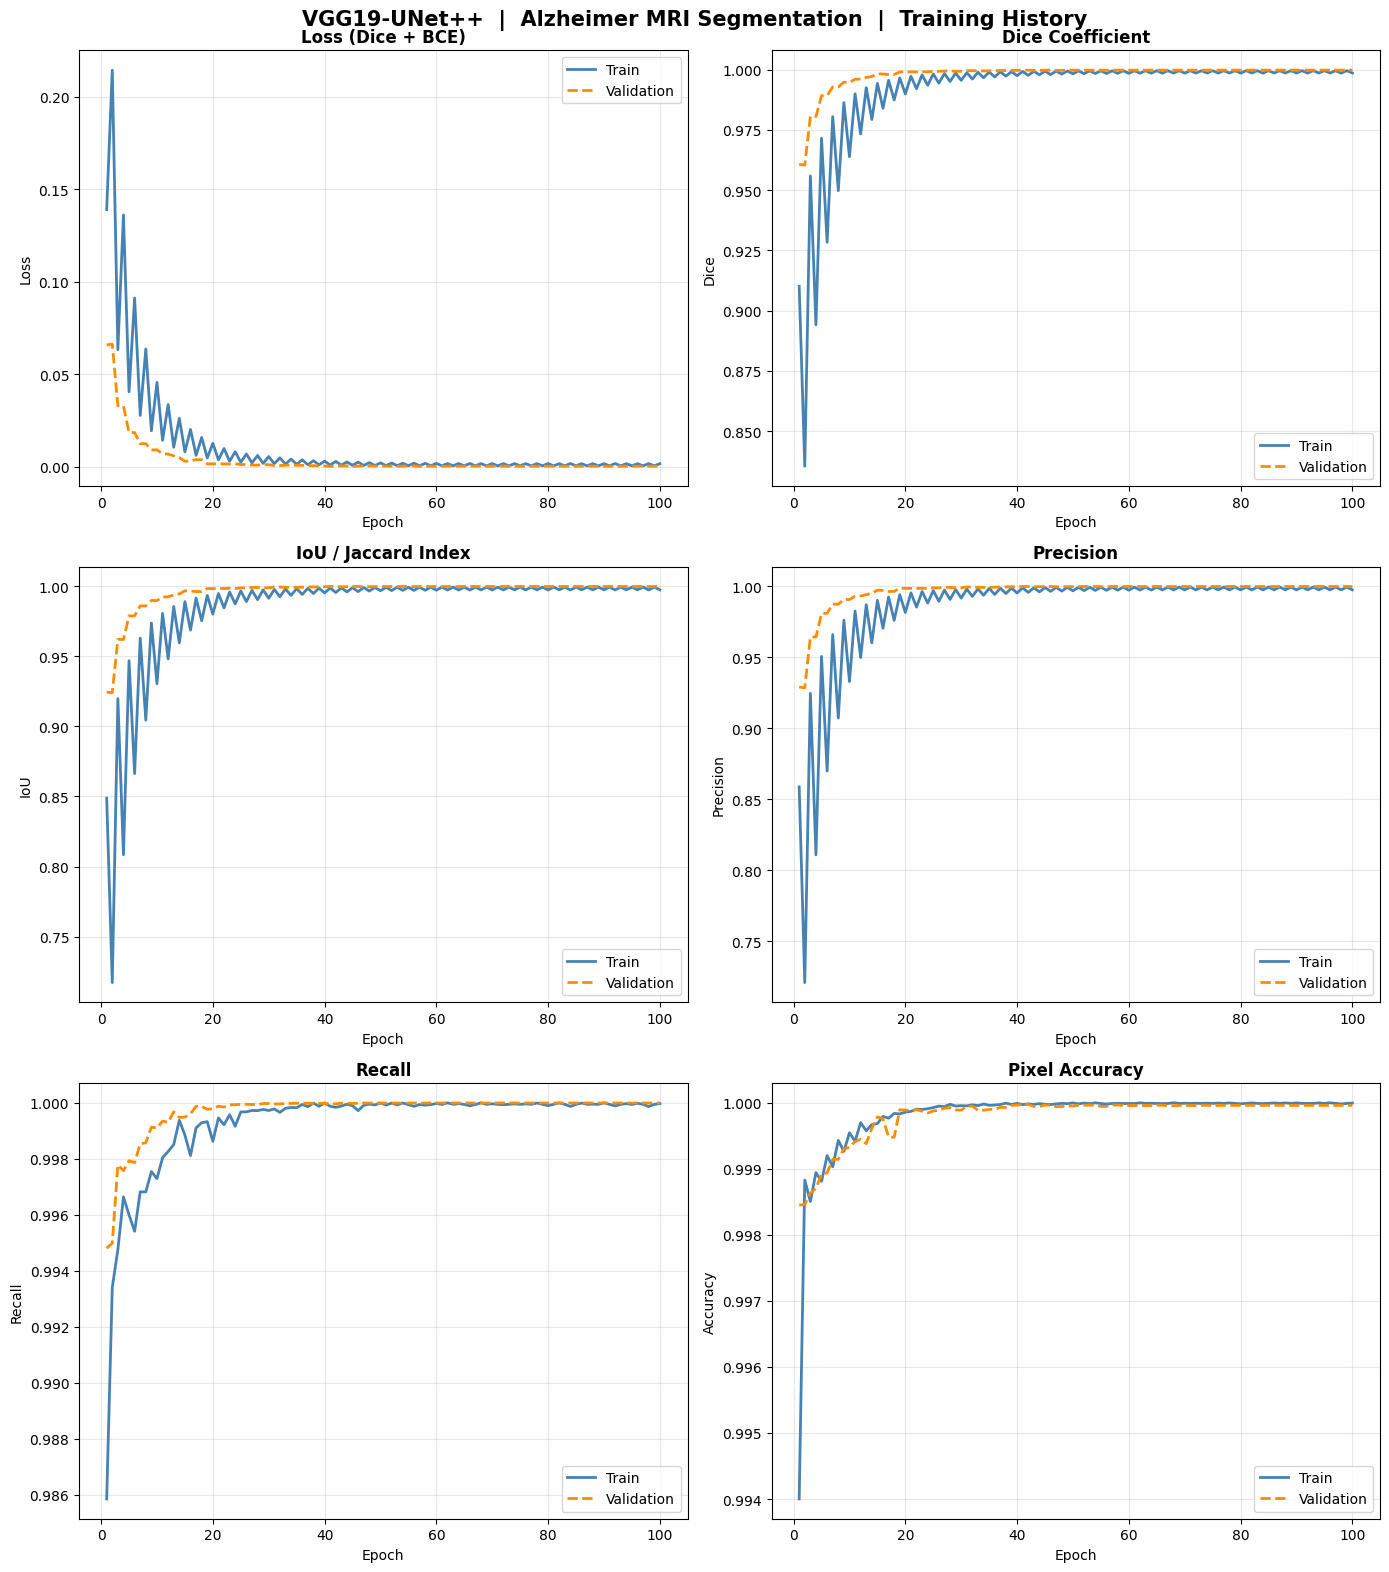

Plot saved → training_history_vgg19unetpp.png


In [28]:
H = history.history

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle('VGG19-UNet++  |  Alzheimer MRI Segmentation  |  Training History',
             fontsize=15, fontweight='bold', y=0.98)

plot_specs = [
    ('loss',             'val_loss',             'Loss (Dice + BCE)',      'Loss',     'upper right'),
    ('dice_coefficient', 'val_dice_coefficient', 'Dice Coefficient',       'Dice',     'lower right'),
    ('iou_score',        'val_iou_score',        'IoU / Jaccard Index',    'IoU',      'lower right'),
    ('precision_smooth', 'val_precision_smooth', 'Precision',              'Precision','lower right'),
    ('recall_smooth',    'val_recall_smooth',    'Recall',                 'Recall',   'lower right'),
    ('pixel_accuracy',   'val_pixel_accuracy',   'Pixel Accuracy',         'Accuracy', 'lower right'),
]

for ax, (train_key, val_key, title, ylabel, loc) in zip(axes.flatten(), plot_specs):
    epochs_range = range(1, len(H[train_key]) + 1)
    ax.plot(epochs_range, H[train_key], label='Train',      color='steelblue',   linewidth=2)
    ax.plot(epochs_range, H[val_key],   label='Validation', color='darkorange',  linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(loc=loc, fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_vgg19unetpp.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → training_history_vgg19unetpp.png')

## 14. Best & Average Metrics Table

In [ ]:
metric_spec = [
    ('Loss',           'loss',             'min'),
    ('Dice',           'dice_coefficient', 'max'),
    ('IoU (Jaccard)',  'iou_score',        'max'),
    ('Precision',      'precision_smooth', 'max'),
    ('Recall',         'recall_smooth',    'max'),
    ('Pixel Accuracy', 'pixel_accuracy',   'max'),
]

rows = []
for disp, key, mode in metric_spec:
    tr = np.asarray(H[key],          dtype=np.float64)
    va = np.asarray(H['val_' + key], dtype=np.float64)
    pick = np.min if mode == 'min' else np.max
    rows.append({
        'Metric':     disp,
        'Train Best': pick(tr), 'Train Avg': tr.mean(),
        'Val Best':   pick(va), 'Val Avg':   va.mean(),
    })

def f1_curve(p, r):
    p = np.asarray(p, dtype=np.float64); r = np.asarray(r, dtype=np.float64)
    return 2.0 * p * r / (p + r + 1e-7)

tr_f1 = f1_curve(H['precision_smooth'],     H['recall_smooth'])
va_f1 = f1_curve(H['val_precision_smooth'], H['val_recall_smooth'])
rows.append({'Metric': 'F1-Score',
             'Train Best': tr_f1.max(), 'Train Avg': tr_f1.mean(),
             'Val Best':   va_f1.max(), 'Val Avg':   va_f1.mean()})

report = pd.DataFrame(rows).set_index('Metric').round(4)

print('=' * 68)
print('   BEST & AVERAGE METRICS  —  VGG19-UNet++  |  OASIS disc1+disc2')
print('=' * 68)
print(report.to_string())
print('=' * 68)

best_epoch_iou  = int(np.argmax(H['val_iou_score']))  + 1
best_epoch_dice = int(np.argmax(H['val_dice_coefficient'])) + 1
print(f'\nBest Val IoU : {max(H["val_iou_score"]):.4f}  (epoch {best_epoch_iou})')
print(f'Best Val Dice: {max(H["val_dice_coefficient"]):.4f}  (epoch {best_epoch_dice})')

# Overfitting check — gap between train and val at final epoch
final_gap_iou  = H['val_iou_score'][-1]  - H['iou_score'][-1]
final_gap_dice = H['val_dice_coefficient'][-1] - H['dice_coefficient'][-1]
print(f'\nFinal-epoch Val-Train gap → IoU: {final_gap_iou:+.4f}, Dice: {final_gap_dice:+.4f}')
print('(Large positive gap can indicate train metrics still catching up;')
print(' large negative gap with val dropping while train keeps rising = overfitting.)')

report

   BEST & AVERAGE METRICS  —  VGG19-UNet++  |  OASIS disc1+disc2
                Train Best  Train Avg  Val Best  Val Avg
Metric                                                  
Loss                0.0005     0.0114    0.0003   0.0036
Dice                0.9996     0.9914    0.9998   0.9979
IoU (Jaccard)       0.9992     0.9842    0.9997   0.9959
Precision           0.9993     0.9847    0.9997   0.9962
Recall              1.0000     0.9993    1.0000   0.9997
Pixel Accuracy      1.0000     0.9998    1.0000   0.9998
F1-Score            0.9996     0.9915    0.9998   0.9979

Best Val IoU : 0.9997  (epoch 57)
Best Val Dice: 0.9998  (epoch 57)

Final-epoch Val-Train gap → IoU: +0.0024, Dice: +0.0012
(Large positive gap can indicate train metrics still catching up;
 large negative gap with val dropping while train keeps rising = overfitting.)


,Train Best,Train Avg,Val Best,Val Avg
Metric,,,,
Loss,0.0005,0.0114,0.0003,0.0036
Dice,0.9996,0.9914,0.9998,0.9979
IoU (Jaccard),0.9992,0.9842,0.9997,0.9959
Precision,0.9993,0.9847,0.9997,0.9962
Recall,1.0000,0.9993,1.0000,0.9997
Pixel Accuracy,1.0000,0.9998,1.0000,0.9998
F1-Score,0.9996,0.9915,0.9998,0.9979


## 15. Load Best Model & Final Evaluation

In [ ]:
best_model = tf.keras.models.load_model(
    'best_model_vgg19unetpp.keras',
    custom_objects={
        'combined_loss':   combined_loss,
        'dice_coefficient': dice_coefficient,
        'iou_score':        iou_score,
        'precision_smooth': precision_smooth,
        'recall_smooth':    recall_smooth,
        'pixel_accuracy':   pixel_accuracy,
    }
)
print('Best model loaded ✓')
best_model.summary()

Best model loaded ✓


Model: "VGG19_UNetPP"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input[0][0]       │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv4        │ (None, 56, 56,    │    590,080 │ block3_conv3[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv4[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv4        │ (None, 28, 28,    │  2,359,808 │ block4_conv3[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv4[0][

 Total params: 66,288,645 (252.87 MB)

 Trainable params: 15,419,201 (58.82 MB)

 Non-trainable params: 20,031,040 (76.41 MB)

 Optimizer params: 30,838,404 (117.64 MB)

In [ ]:
print('Evaluating best model on held-out test set...\n')
test_results = best_model.evaluate(test_dataset, verbose=1)
test_dict    = dict(zip(best_model.metrics_names, test_results))

label_map = {
    'loss': 'Loss', 'dice_coefficient': 'Dice', 'iou_score': 'IoU (Jaccard)',
    'precision_smooth': 'Precision', 'recall_smooth': 'Recall', 'pixel_accuracy': 'Pixel Accuracy'
}

P = test_dict.get('precision_smooth', 0)
R = test_dict.get('recall_smooth',    0)
f1 = 2 * P * R / (P + R + 1e-7)

print('\n' + '=' * 60)
print('  FINAL TEST-SET METRICS  (VGG19-UNet++ | OASIS disc1+disc2)')
print('=' * 60)
for k, v in test_dict.items():
    print(f'  {label_map.get(k, k):20s}: {v:.4f}')
print(f'  {"F1-Score":20s}: {f1:.4f}')
print('=' * 60)

final_df = pd.DataFrame([{
    'Model':      'VGG19-UNet++ (OASIS disc1+disc2)',
    'IoU':        round(test_dict.get('iou_score', float('nan')), 4),
    'Dice':       round(test_dict.get('dice_coefficient', float('nan')), 4),
    'Precision':  round(P, 4),
    'Recall':     round(R, 4),
    'Accuracy':   round(test_dict.get('pixel_accuracy', float('nan')), 4),
    'F1':         round(f1, 4),
}]).set_index('Model')
final_df

Evaluating best model on held-out test set...

62/63 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - dice_coefficient: 0.9998 - iou_score: 0.9997 - loss: 2.9481e-04 - pixel_accuracy: 1.0000 - precision_smooth: 0.9997 - recall_smooth: 1.0000

2026-06-21 16:18:04.745574: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-21 16:18:04.990185: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-21 16:18:06.791808: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-21 16:18:07.048939: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-21 16:18:09.138090: E external/local_xla/xla/stream_

63/63 ━━━━━━━━━━━━━━━━━━━━ 29s 396ms/step - dice_coefficient: 0.9998 - iou_score: 0.9997 - loss: 3.1315e-04 - pixel_accuracy: 1.0000 - precision_smooth: 0.9997 - recall_smooth: 1.0000

  FINAL TEST-SET METRICS  (VGG19-UNet++ | OASIS disc1+disc2)
  Loss                : 0.0003
  compile_metrics     : 0.9998
  F1-Score            : 0.0000


,IoU,Dice,Precision,Recall,Accuracy,F1
Model,,,,,,
VGG19-UNet++ (OASIS disc1+disc2),NaN,NaN,0,0,NaN,0.0


## 16. Test Predictions Visualization

Test set predictions:


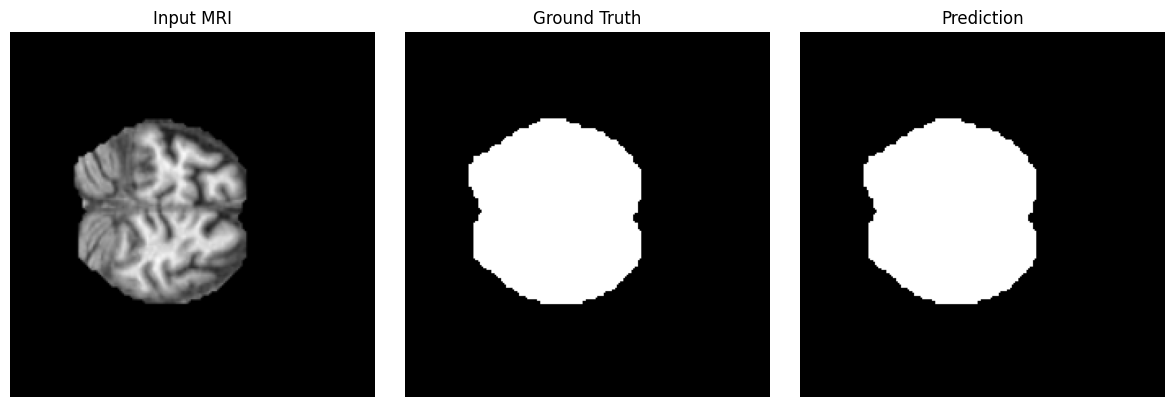

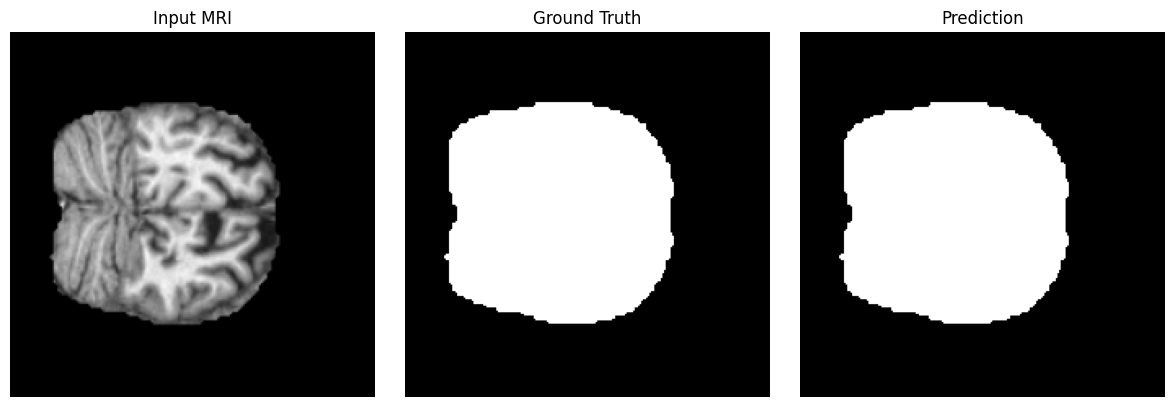

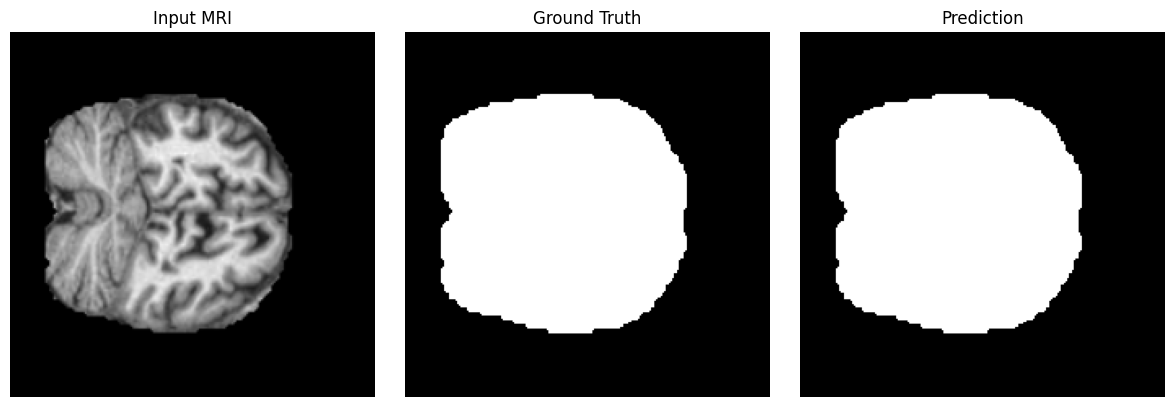

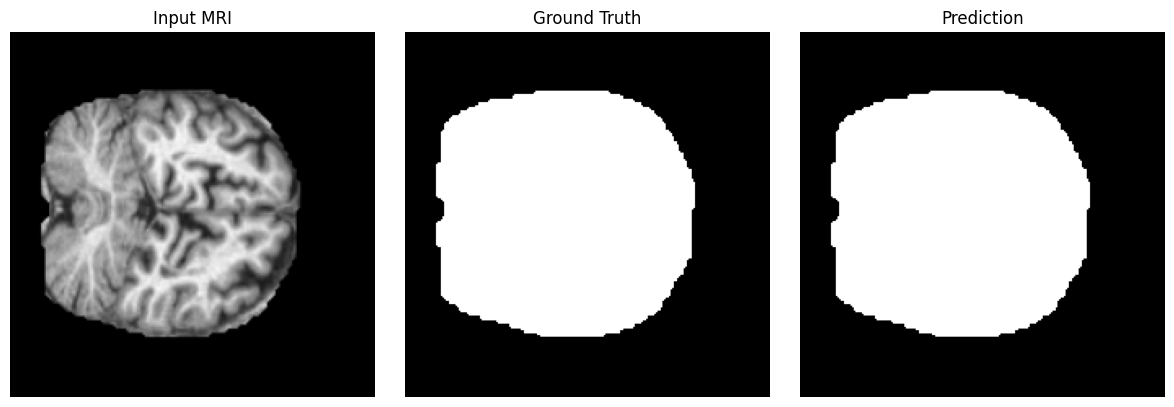

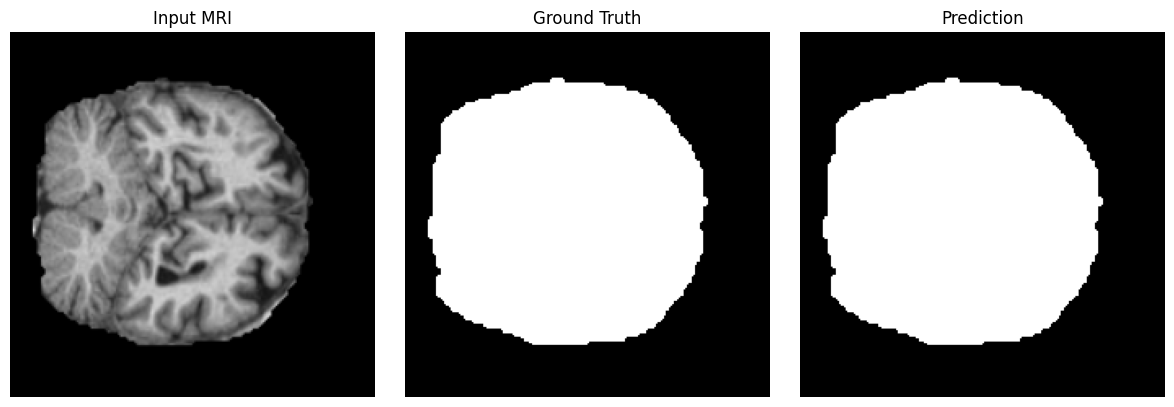

In [ ]:
print('Test set predictions:')
show_predictions(test_dataset, num=5, model_to_use=best_model)

## 17. Detailed Prediction Grid

2026-06-21 16:18:19.676489: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-21 16:18:19.921982: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-21 16:18:22.964299: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-21 16:18:23.223124: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-21 16:18:26.686321: E external/local_xla/xla/stream_

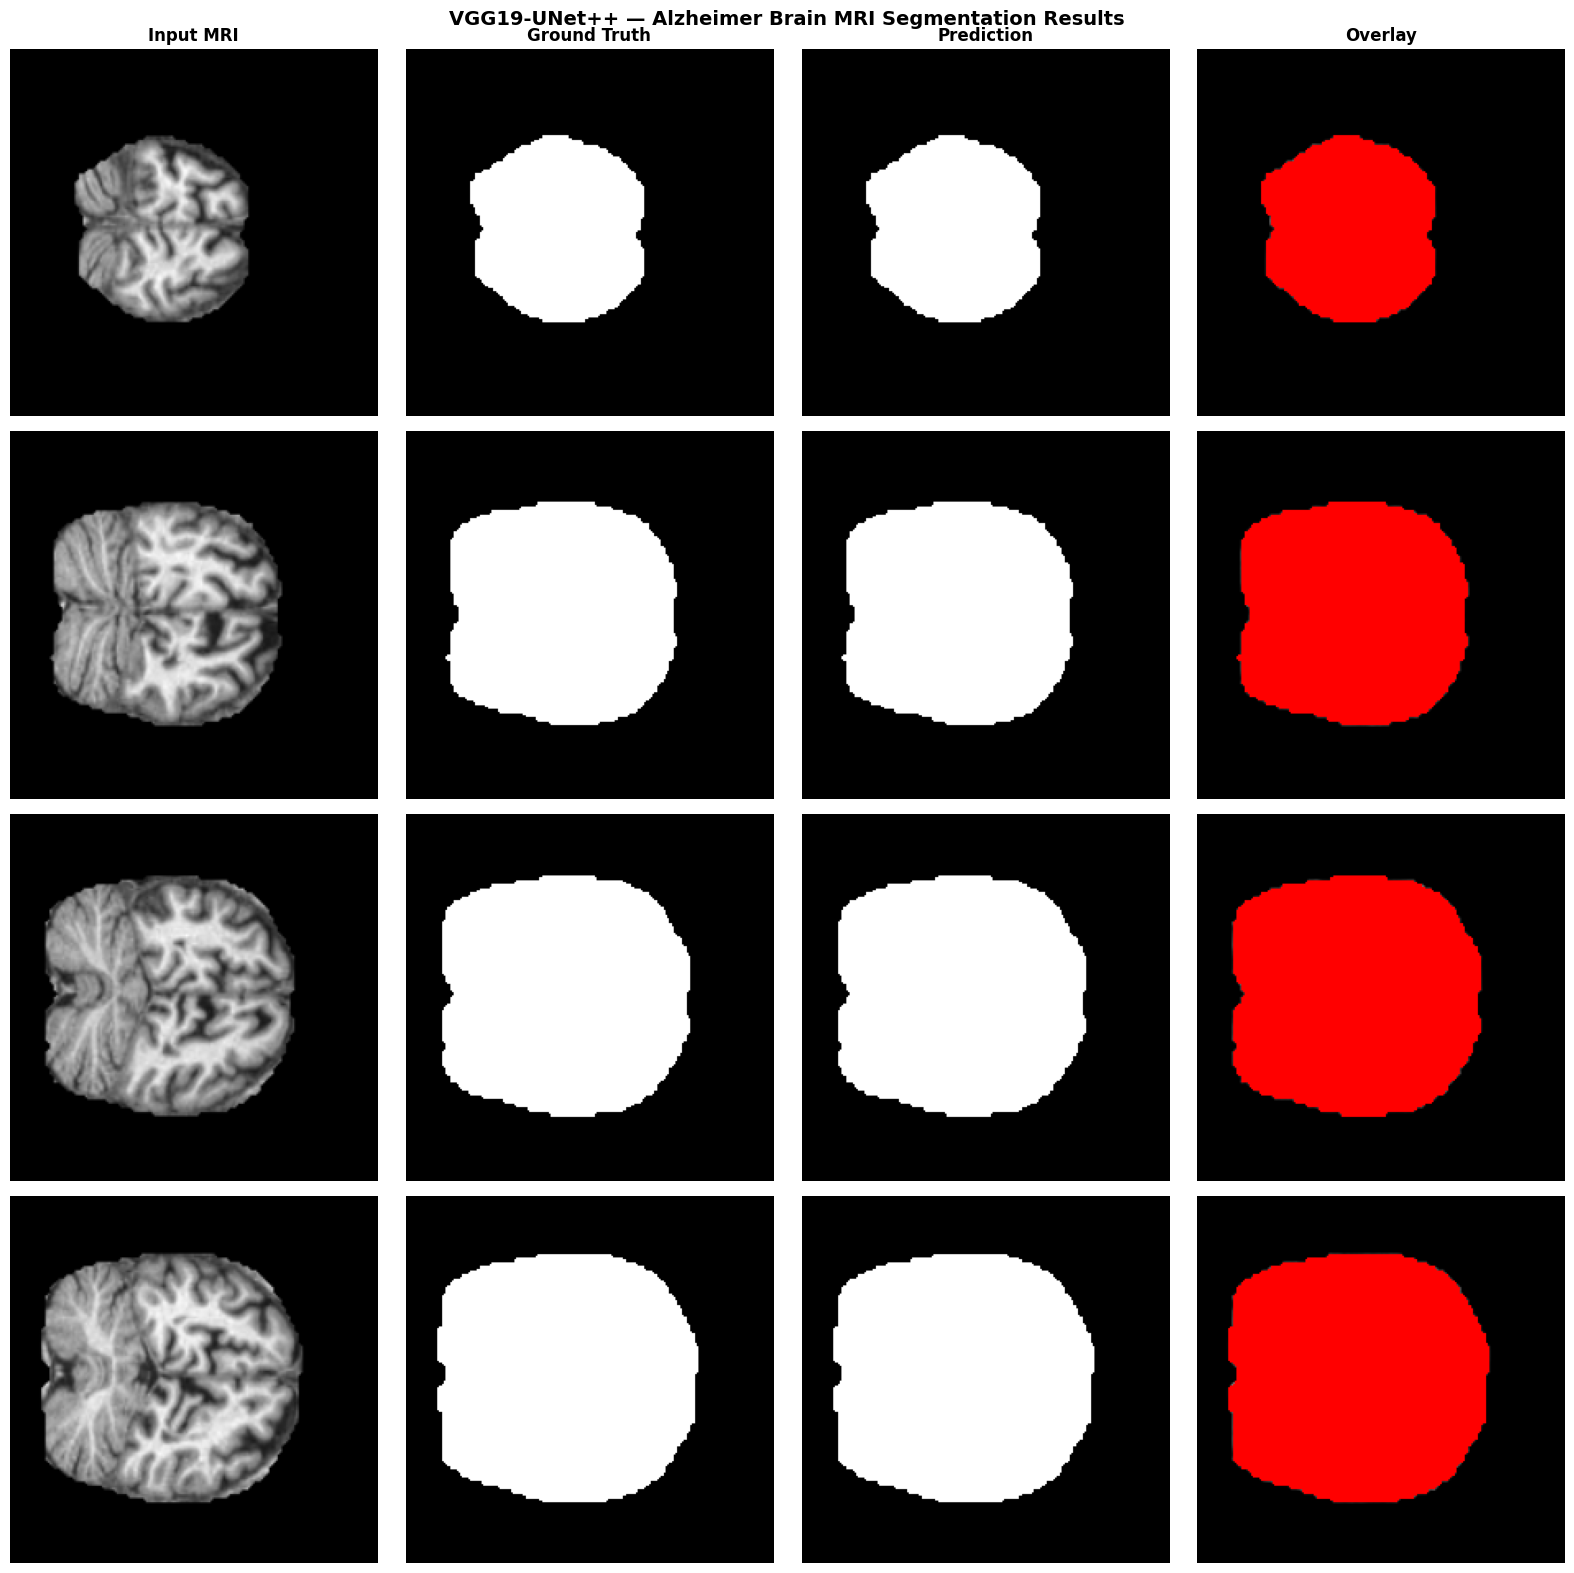

Grid saved → prediction_grid_vgg19unetpp.png


In [ ]:
def prediction_grid(dataset, best_model, n_rows=4):
    for imgs, masks in dataset.take(1):
        preds = best_model.predict(imgs[:n_rows], verbose=0)

        fig, axes = plt.subplots(n_rows, 4, figsize=(16, 4 * n_rows))
        col_titles = ['Input MRI', 'Ground Truth', 'Prediction', 'Overlay']
        for col, t in enumerate(col_titles):
            axes[0, col].set_title(t, fontsize=12, fontweight='bold')

        for row in range(n_rows):
            img   = imgs[row].numpy()
            gt    = masks[row].numpy()[..., 0]
            pred  = create_mask(preds[row]).numpy()[..., 0]

            ov = (img * 255).astype(np.uint8)
            ov[pred > 0.5, 0] = 255
            ov[pred > 0.5, 1] = 0
            ov[pred > 0.5, 2] = 0

            inter = np.sum(gt * pred)
            union = np.sum(gt) + np.sum(pred) - inter
            sample_iou = (inter + 1) / (union + 1)

            axes[row, 0].imshow(img)
            axes[row, 1].imshow(gt,   cmap='gray')
            axes[row, 2].imshow(pred, cmap='gray')
            axes[row, 2].set_xlabel(f'IoU: {sample_iou:.3f}', fontsize=10, color='green')
            axes[row, 3].imshow(ov)

            for col in range(4):
                axes[row, col].axis('off')

        plt.suptitle('VGG19-UNet++ — Alzheimer Brain MRI Segmentation Results',
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('prediction_grid_vgg19unetpp.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('Grid saved → prediction_grid_vgg19unetpp.png')


prediction_grid(test_dataset, best_model, n_rows=4)

## 18. IoU Distribution Plot

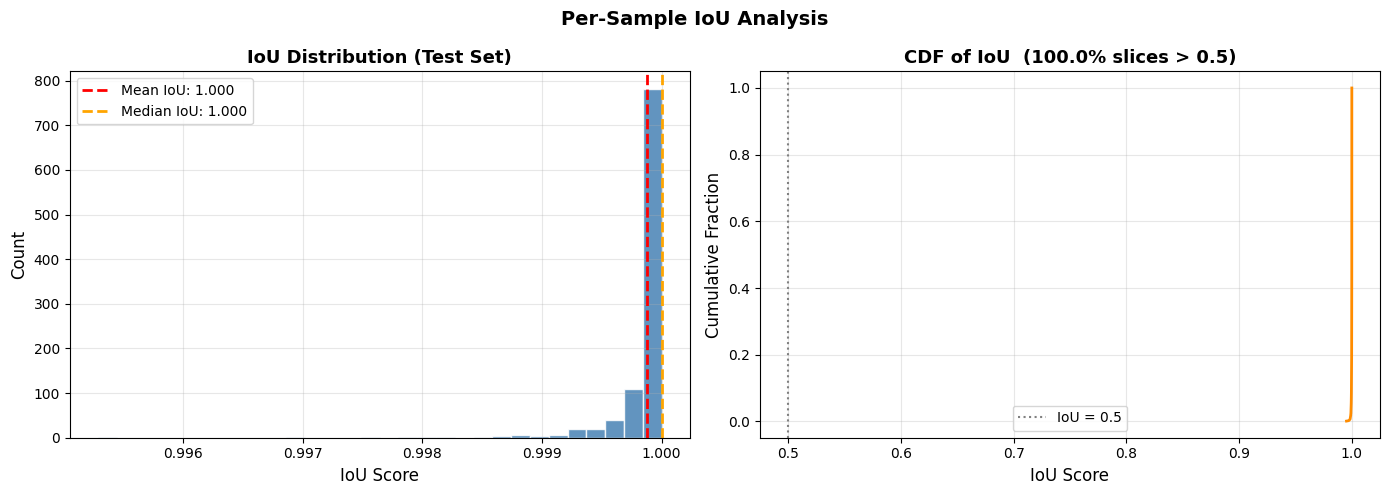


IoU Stats — Mean: 0.9999  |  Std: 0.0003
             Min : 0.9953  |  Max: 1.0000
% slices IoU > 0.5 : 100.0%


In [ ]:
iou_scores = []

for imgs, masks in test_dataset:
    preds = best_model.predict(imgs, verbose=0)
    for i in range(len(imgs)):
        gt   = masks[i].numpy()[..., 0]
        pred = (preds[i][..., 0] > 0.5).astype(float)
        inter = np.sum(gt * pred)
        union = np.sum(gt) + np.sum(pred) - inter
        iou_scores.append((inter + 1) / (union + 1))

iou_arr = np.array(iou_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(iou_arr, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(iou_arr.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean IoU: {iou_arr.mean():.3f}')
axes[0].axvline(np.median(iou_arr), color='orange', linestyle='--', linewidth=2,
                label=f'Median IoU: {np.median(iou_arr):.3f}')
axes[0].set_xlabel('IoU Score', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('IoU Distribution (Test Set)', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sorted_iou = np.sort(iou_arr)
cdf = np.arange(1, len(sorted_iou) + 1) / len(sorted_iou)
axes[1].plot(sorted_iou, cdf, color='darkorange', linewidth=2)
axes[1].axvline(0.5, color='gray', linestyle=':', label='IoU = 0.5')
pct_above_50 = np.mean(iou_arr > 0.5) * 100
axes[1].set_xlabel('IoU Score', fontsize=12)
axes[1].set_ylabel('Cumulative Fraction', fontsize=12)
axes[1].set_title(f'CDF of IoU  ({pct_above_50:.1f}% slices > 0.5)', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Per-Sample IoU Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('iou_distribution_vgg19unetpp.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nIoU Stats — Mean: {iou_arr.mean():.4f}  |  Std: {iou_arr.std():.4f}')
print(f'             Min : {iou_arr.min():.4f}  |  Max: {iou_arr.max():.4f}')
print(f'% slices IoU > 0.5 : {pct_above_50:.1f}%')

## 19. Save Final Model

In [ ]:

best_model.save('alzheimer_vgg19_unetpp_final.keras')
print('Model saved → alzheimer_vgg19_unetpp_final.keras')

Model saved → alzheimer_vgg19_unetpp_final.keras
